# Reciprocal Inhibition in Two Leaky Integrate-and-Fire Neurons

## Objective

To investigate how the strength of reciprocal inhibitory synaptic connections influences the firing dynamics of two mutually inhibitory Leaky Integrate-and-Fire (LIF) neurons using the MOOSE simulation framework.


## 1. Project Overview

This project uses the MOOSE (Multiscale Object-Oriented Simulation Environment) framework to investigate interactions between two mutually inhibitory Leaky Integrate-and-Fire (LIF) neurons.

Each neuron receives a constant tonic input current that drives its membrane potential toward threshold. When a neuron reaches threshold, a SpikeGen detects the spike and transmits it through a synaptic handler and inhibitory synaptic channel to the other neuron.

Two network conditions are investigated:

1. **Strong mutual inhibition:** One neuron dominates and suppresses the other, producing a winner-take-all state.
2. **Weak mutual inhibition:** Both neurons remain capable of firing and influence each other's spike timing, producing competitive network activity.

The project demonstrates how changes in synaptic strength and relative neuronal drive can produce different emergent firing patterns in a simple neuronal network.

## 2. Model Architecture

The computational network consists of two Leaky Integrate-and-Fire (LIF) neurons, referred to as Neuron A and Neuron B.

Both neurons receive constant tonic input currents. Each neuron is connected to a SpikeGen object that detects when its membrane potential reaches the firing threshold and generates a spike event.

The spike output is transmitted through a synaptic handler to an inhibitory SynChan connected to the other neuron. Therefore, the network contains two reciprocal inhibitory pathways:

**Neuron A → SpikeGen → SynHandler → SynChan → Neuron B**

**Neuron B → SpikeGen → SynHandler → SynChan → Neuron A**

The synaptic reversal potential is set below the resting membrane potential, making both connections inhibitory. Consequently, activity in either neuron can suppress or delay activity in the other neuron.

Two different inhibitory strengths are subsequently investigated to examine how synaptic strength affects the overall network dynamics.

## 3. MOOSE Model Setup

The neuronal network was implemented using the MOOSE simulation framework (version 4.3.1).

The model was constructed from basic MOOSE components, including LIF neurons, SpikeGen objects, SynHandler objects, and inhibitory SynChan objects.

Before constructing the network, the simulation environment is initialized and any previous experimental model and recorded data are removed. This ensures that each experiment starts from a clean model state.

In [2]:
!apt-get update -qq
!apt-get install -y -qq libgsl-dev libhdf5-dev
!pip install -q pymoose

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Selecting previously unselected package libgslcblas0:amd64.
(Reading database ... 118419 files and directories currently installed.)
Preparing to unpack .../libgslcblas0_2.7.1+dfsg-3_amd64.deb ...
Unpacking libgslcblas0:amd64 (2.7.1+dfsg-3) ...
Selecting previously unselected package libgsl27:amd64.
Preparing to unpack .../libgsl27_2.7.1+dfsg-3_amd64.deb ...
Unpacking libgsl27:amd64 (2.7.1+dfsg-3) ...
Selecting previously unselected package libgsl-dev.
Preparing to unpack .../libgsl-dev_2.7.1+dfsg-3_amd64.deb ...
Unpacking libgsl-dev (2.7.1+dfsg-3) ...
Setting up libgslcblas0:amd64 (2.7.1+dfsg-3) ...
Setting up libgsl27:amd64 (2.7.1+dfsg-3) ...
Setting up libgsl-dev (2.7.1+dfsg-3) ...
Processing triggers for man-db (2.10.2-1) ...
Processing triggers for libc-bin (2.35-0ubuntu3.14) ...
/sbin/ldconfig.

In [12]:
import moose

print("MOOSE imported successfully!")
print("MOOSE version:", moose.__version__)

test = moose.HHChannel("/test_channel")

print("Successfully created a MOOSE HHChannel!")
print("Object path:", test.path)

moose.le("/")

MOOSE imported successfully!
MOOSE version: 4.3.1
Successfully created a MOOSE HHChannel!
Object path: /test_channel[0]
Elements under /
    /Msgs
    /clock
    /classes
    /postmaster
    /test_channel
    /data
    /model



In [13]:
import moose


# Creating model and data containers

moose.Neutral("/model")
moose.Neutral("/data")

# Creating one integrate-and-fire neuron

neuron = moose.IntFire("/model/neuron")

print("Neuron created successfully!")
print("Neuron path:", neuron.path)

Neuron created successfully!
Neuron path: /model[0]/neuron[0]


In [16]:
print(neuron.getFieldNames('valueFinfo'))

['Cm', 'Em', 'Im', 'Ra', 'Rm', 'Vm', 'children', 'className', 'coords', 'destFields', 'diameter', 'dt', 'fieldIndex', 'hasFired', 'idValue', 'index', 'initVm', 'inject', 'lastEventTime', 'length', 'me', 'msgIn', 'msgOut', 'name', 'numData', 'numField', 'parent', 'path', 'refractoryPeriod', 'sourceFields', 'this', 'thresh', 'tick', 'vReset', 'valueFields', 'x', 'x0', 'y', 'y0', 'z', 'z0']


In [18]:
# Creating a clean LIF neuron for our tonic-current experiment

moose.delete("/model")


moose.Neutral("/model")
moose.Neutral("/data")


neuron = moose.LIF("/model/neuron")


# Basic LIF parameters
neuron.Cm = 1e-9
neuron.Rm = 1e7
neuron.Em = -0.065
neuron.initVm = -0.065


# Spike parameters

neuron.thresh = -0.050
neuron.refractoryPeriod = 0.002

# CONSTANT tonic current

neuron.inject = 2e-9


print("LIF neuron created.")
print("Cm =", neuron.Cm)
print("Rm =", neuron.Rm)
print("Em =", neuron.Em)
print("threshold =", neuron.thresh)
print("constant current =", neuron.inject)

LIF neuron created.
Cm = 1e-09
Rm = 10000000.0
Em = -0.065
threshold = -0.05
constant current = 2e-09


In [20]:
import numpy as np
import matplotlib.pyplot as plt


# Creating a table to record membrane voltage

vm_table = moose.Table("/data/Vm")

# Connecting the neuron's membrane voltage to the recording table

moose.connect(vm_table, "requestOut", neuron, "getVm")


# Setting the simulation timestep

dt = 1e-4
moose.setClock(0, dt)
moose.setClock(1, dt)

# Scheduling the neuron and recording table

moose.useClock(0, "/model/neuron", "process")
moose.useClock(1, "/data/Vm", "process")


# Initializing the model

moose.reinit()


# Running for 1 second

moose.start(1.0)

# Getting recorded voltage

vm = np.array(vm_table.vector)


# Creating time axis

time = np.arange(len(vm)) * dt


print("Simulation completed.")
print("Number of recorded points:", len(vm))
print("Minimum Vm:", vm.min())
print("Maximum Vm:", vm.max())

Simulation completed.
Number of recorded points: 20002
Minimum Vm: -0.065
Maximum Vm: 0.0


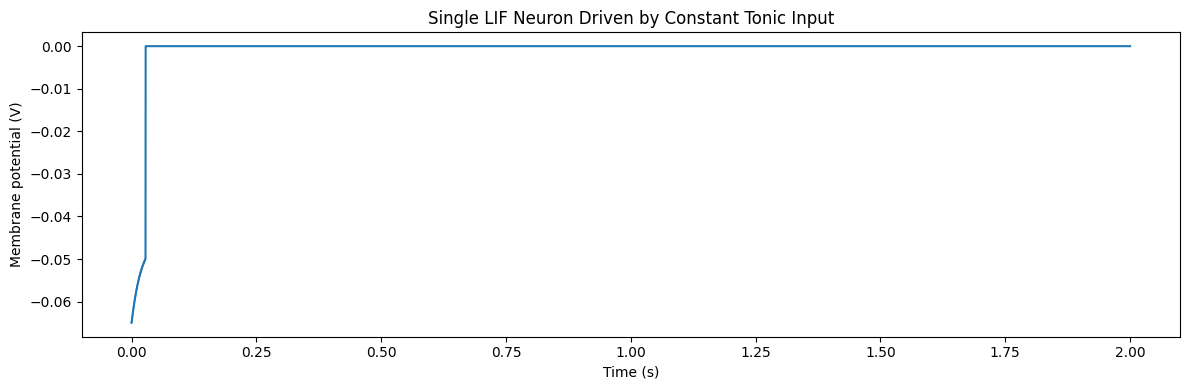

In [21]:
plt.figure(figsize=(12, 4))

plt.plot(time, vm)

plt.xlabel("Time (s)")
plt.ylabel("Membrane potential (V)")
plt.title("Single LIF Neuron Driven by Constant Tonic Input")

plt.tight_layout()
plt.show()

In [22]:
print(neuron.getFieldNames('valueFinfo'))

['Cm', 'Em', 'Im', 'Ra', 'Rm', 'Vm', 'children', 'className', 'coords', 'destFields', 'diameter', 'dt', 'fieldIndex', 'hasFired', 'idValue', 'index', 'initVm', 'inject', 'lastEventTime', 'length', 'me', 'msgIn', 'msgOut', 'name', 'numData', 'numField', 'parent', 'path', 'refractoryPeriod', 'sourceFields', 'this', 'thresh', 'tick', 'vReset', 'valueFields', 'x', 'x0', 'y', 'y0', 'z', 'z0']


In [23]:
# Setting the reset voltage explicitly
neuron.vReset = -0.065


print("Threshold:", neuron.thresh, "V")
print("Reset voltage:", neuron.vReset, "V")
print("Constant current:", neuron.inject, "A")

Threshold: -0.05 V
Reset voltage: -0.065 V
Constant current: 2e-09 A


Simulation completed.
Minimum Vm: -0.065
Maximum Vm: -0.04998150609263327


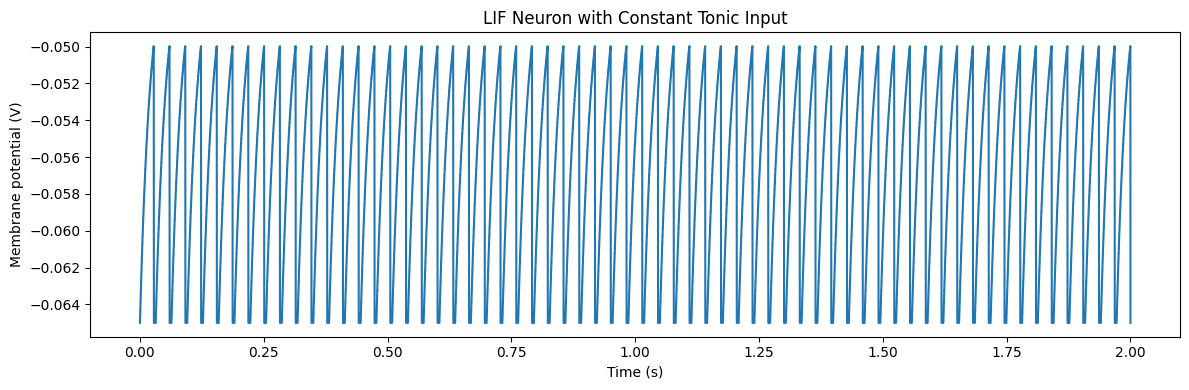

In [24]:
# Re-running the simulation with the explicit reset voltage

moose.reinit()
moose.start(1.0)


vm = np.array(vm_table.vector)
time = np.arange(len(vm)) * dt


print("Simulation completed.")
print("Minimum Vm:", vm.min())
print("Maximum Vm:", vm.max())



plt.figure(figsize=(12, 4))
plt.plot(time, vm)



plt.xlabel("Time (s)")
plt.ylabel("Membrane potential (V)")
plt.title("LIF Neuron with Constant Tonic Input")



plt.tight_layout()
plt.show()

In [25]:
print("SOURCE fields:")
print(neuron.getFieldNames('srcFinfo'))


print("\nDESTINATION fields:")
print(neuron.getFieldNames('destFinfo'))

SOURCE fields:
['VmOut', 'axialOut', 'childOut', 'raxialOut', 'spikeOut']

DESTINATION fields:
['activation', 'cable', 'displace', 'getChildren', 'getClassName', 'getCm', 'getCoords', 'getDestFields', 'getDiameter', 'getDt', 'getEm', 'getFieldIndex', 'getHasFired', 'getIdValue', 'getIm', 'getIndex', 'getInitVm', 'getInject', 'getIsA', 'getLastEventTime', 'getLength', 'getMe', 'getMsgDestFunctions', 'getMsgDests', 'getMsgIn', 'getMsgOut', 'getName', 'getNeighbors', 'getNumData', 'getNumField', 'getParent', 'getPath', 'getRa', 'getRefractoryPeriod', 'getRm', 'getSourceFields', 'getThis', 'getThresh', 'getTick', 'getVReset', 'getValueFields', 'getVm', 'getX', 'getX0', 'getY', 'getY0', 'getZ', 'getZ0', 'handleAxial', 'handleChannel', 'handleRaxial', 'initProc', 'initReinit', 'injectMsg', 'notifyAddMsgDest', 'notifyAddMsgSrc', 'notifyCopy', 'notifyCreate', 'notifyDestroy', 'notifyMove', 'parentMsg', 'process', 'randInject', 'reinit', 'setCm', 'setCoords', 'setDiameter', 'setEm', 'setGeomAnd

In [26]:
# Cleaning up the previous model

moose.delete("/model")
moose.delete("/data")


# Creating model and recording containers

moose.Neutral("/model")
moose.Neutral("/data")


# Creating two LIF neurons

neuron_A = moose.LIF("/model/neuron_A")
neuron_B = moose.LIF("/model/neuron_B")


# -----------------------------
# Common neuron parameters
# -----------------------------


for neuron in [neuron_A, neuron_B]:
    neuron.Cm = 1e-9
    neuron.Rm = 1e7
    neuron.Em = -0.065
    neuron.initVm = -0.065
    neuron.thresh = -0.050
    neuron.vReset = -0.065
    neuron.refractoryPeriod = 0.002

# Constant tonic input to both neurons

neuron_A.inject = 2e-9
neuron_B.inject = 2e-9

# -----------------------------
# Connecting A → B
# -----------------------------

moose.connect(neuron_A, "spikeOut", neuron_B, "activation")

print("Two LIF neurons created.")
print("Neuron A:", neuron_A.path)
print("Neuron B:", neuron_B.path)
print("A → B connection created.")

Two LIF neurons created.
Neuron A: /model[0]/neuron_A[0]
Neuron B: /model[0]/neuron_B[0]
A → B connection created.


In [27]:
# Creating recording tables for both neurons

vm_A = moose.Table("/data/Vm_A")
vm_B = moose.Table("/data/Vm_B")


# Recording membrane potentials

moose.connect(vm_A, "requestOut", neuron_A, "getVm")
moose.connect(vm_B, "requestOut", neuron_B, "getVm")

# Simulation timestep

dt = 1e-4


moose.setClock(0, dt)
moose.setClock(1, dt)


# Scheduling neurons

moose.useClock(0, "/model/neuron_A", "process")
moose.useClock(0, "/model/neuron_B", "process")


# Scheduling recording

moose.useClock(1, "/data/Vm_A", "process")
moose.useClock(1, "/data/Vm_B", "process")


# Initializing and simulate

moose.reinit()
moose.start(0.5)


# Retrieving data

vm_A_data = np.array(vm_A.vector)
vm_B_data = np.array(vm_B.vector)

time_2 = np.arange(len(vm_A_data)) * dt

print("Simulation completed.")
print("Recorded points:", len(vm_A_data))
print("A minimum Vm:", vm_A_data.min())
print("A maximum Vm:", vm_A_data.max())
print("B minimum Vm:", vm_B_data.min())
print("B maximum Vm:", vm_B_data.max())

Simulation completed.
Recorded points: 5001
A minimum Vm: -0.065
A maximum Vm: -0.04998150609263327
B minimum Vm: -0.065
B maximum Vm: -0.04998150609263327


In [28]:
# Inspecting the synaptic classes available in this MOOSE installation

print("SimpleSynHandler:", moose.exists("/classes/SimpleSynHandler"))
print("SynChan:", moose.exists("/classes/SynChan"))
print("SpikeGen:", moose.exists("/classes/SpikeGen"))

SimpleSynHandler: True
SynChan: True
SpikeGen: True


In [30]:
print("SimpleSynHandler SOURCE fields:")
print(handler_B.getFieldNames('srcFinfo'))


print("\nSimpleSynHandler DESTINATION fields:")
print(handler_B.getFieldNames('destFinfo'))

SimpleSynHandler SOURCE fields:
['activationOut', 'childOut']

SimpleSynHandler DESTINATION fields:
['getChildren', 'getClassName', 'getDestFields', 'getDt', 'getFieldIndex', 'getIdValue', 'getIndex', 'getIsA', 'getMe', 'getMsgDestFunctions', 'getMsgDests', 'getMsgIn', 'getMsgOut', 'getName', 'getNeighbors', 'getNumData', 'getNumField', 'getNumSynapse', 'getNumSynapses', 'getParent', 'getPath', 'getSourceFields', 'getThis', 'getTick', 'getValueFields', 'notifyAddMsgDest', 'notifyAddMsgSrc', 'notifyCopy', 'notifyCreate', 'notifyDestroy', 'notifyMove', 'parentMsg', 'process', 'reinit', 'setName', 'setNumData', 'setNumField', 'setNumSynapse', 'setNumSynapses', 'setThis', 'setTick']


In [31]:
print(moose.doc("SynHandlerBase"))

class SynHandlerBase

Base class for handling synapse arrays converging onto a given channel or integrate-and-fire neuron. This class provides the interface for channels/intFires to connect to a range of synapse types, including simple synapses, synapses with different plasticity rules, and variants yet to be implemented. 

Author:   Upi Bhalla 

Attributes:

Value Attributes:
-----------------
children (type: vector<Id>, class: SynHandlerBase)
  vector of ObjIds listing all children of current object 

className (type: string, class: SynHandlerBase)
  Class Name of object 

destFields (type: vector<string>, class: SynHandlerBase)
  List of all destination fields on Element, that is, fieldsthat are accessed 
  as Element functions. 

dt (type: double, class: SynHandlerBase)
  Timestep used for this Element. Zero if not scheduled. 

fieldIndex (type: unsigned int, class: SynHandlerBase)
  For a FieldElement: field Index of self.For a regular Element: zero. 


idValue (type: unsigned int

In [32]:
print(moose.doc("SynHandlerBase"))

class SynHandlerBase

Base class for handling synapse arrays converging onto a given channel or integrate-and-fire neuron. This class provides the interface for channels/intFires to connect to a range of synapse types, including simple synapses, synapses with different plasticity rules, and variants yet to be implemented. 

Author:   Upi Bhalla 

Attributes:

Value Attributes:
-----------------
children (type: vector<Id>, class: SynHandlerBase)
  vector of ObjIds listing all children of current object 

className (type: string, class: SynHandlerBase)
  Class Name of object 

destFields (type: vector<string>, class: SynHandlerBase)
  List of all destination fields on Element, that is, fieldsthat are accessed 
  as Element functions. 

dt (type: double, class: SynHandlerBase)
  Timestep used for this Element. Zero if not scheduled. 

fieldIndex (type: unsigned int, class: SynHandlerBase)
  For a FieldElement: field Index of self.For a regular Element: zero. 


idValue (type: unsigned int

In [35]:
# ------------------------------------------
# Recording A and B membrane potentials
# ------------------------------------------


moose.delete("/data")

moose.Neutral("/data")

vm_A = moose.Table("/data/Vm_A")
vm_B = moose.Table("/data/Vm_B")

moose.connect(vm_A, "requestOut", neuron_A, "getVm")
moose.connect(vm_B, "requestOut", neuron_B, "getVm")


# ------------------------------------------
# Simulation settings
# ------------------------------------------

dt = 1e-4

moose.setClock(0, dt)
moose.setClock(1, dt)

moose.useClock(0, "/model/neuron_A", "process")
moose.useClock(0, "/model/neuron_B", "process")
moose.useClock(0, "/model/spikegen_A", "process")
moose.useClock(0, "/model/handler_B", "process")
moose.useClock(0, "/model/synchan_B", "process")

moose.useClock(1, "/data/Vm_A", "process")
moose.useClock(1, "/data/Vm_B", "process")


# ------------------------------------------
# Running simulation
# ------------------------------------------

moose.reinit()
moose.start(0.2)


# ------------------------------------------
# Retrieving data
# ------------------------------------------

vm_A_data = np.array(vm_A.vector)
vm_B_data = np.array(vm_B.vector)

time = np.arange(len(vm_A_data)) * dt

print("Simulation completed.")
print("Recorded points:", len(vm_A_data))
print("A Vm range:", vm_A_data.min(), "to", vm_A_data.max())
print("B Vm range:", vm_B_data.min(), "to", vm_B_data.max())

Simulation completed.
Recorded points: 2001
A Vm range: -0.065 to -0.04998150609263327
B Vm range: -0.065 to -0.06463741288364921


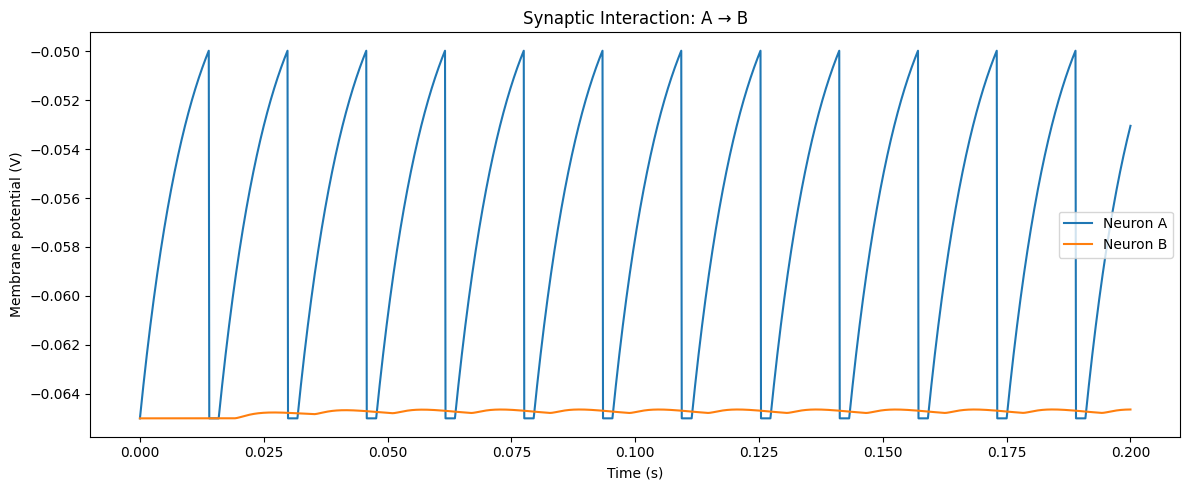

In [36]:
plt.figure(figsize=(12, 5))


plt.plot(time, vm_A_data, label="Neuron A")
plt.plot(time, vm_B_data, label="Neuron B")


plt.xlabel("Time (s)")
plt.ylabel("Membrane potential (V)")
plt.title("Synaptic Interaction: A → B")
plt.legend()
plt.tight_layout()
plt.show()

In [38]:
# ------------------------------------------
# Running the same experiment with inhibition
# ------------------------------------------

moose.reinit()
moose.start(0.2)

vm_A_inh = np.array(vm_A.vector)
vm_B_inh = np.array(vm_B.vector)

time_inh = np.arange(len(vm_A_inh)) * dt

print("Inhibitory synapse simulation completed.")
print("A Vm range:", vm_A_inh.min(), "to", vm_A_inh.max())
print("B Vm range:", vm_B_inh.min(), "to", vm_B_inh.max())

Inhibitory synapse simulation completed.
A Vm range: -0.065 to -0.04998150609263327
B Vm range: -0.0650836739499271 to -0.065


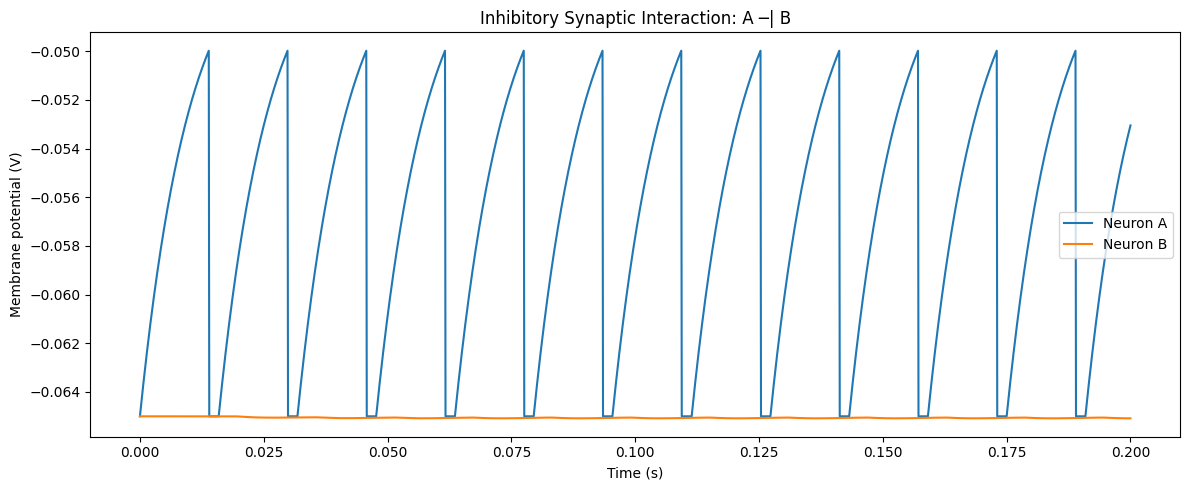

In [39]:
plt.figure(figsize=(12, 5))


plt.plot(time_inh, vm_A_inh, label="Neuron A")
plt.plot(time_inh, vm_B_inh, label="Neuron B")


plt.xlabel("Time (s)")
plt.ylabel("Membrane potential (V)")
plt.title("Inhibitory Synaptic Interaction: A ─| B")
plt.legend()
plt.tight_layout()
plt.show()

In [40]:
# ============================================================
# TWO MUTUALLY INHIBITORY LIF NEURONS
# First oscillator experiment
# ============================================================

# Cleaning previous experimental model
moose.delete("/model")
moose.delete("/data")

moose.Neutral("/model")
moose.Neutral("/data")


# ------------------------------------------------------------
# 1. Creating neurons
# ------------------------------------------------------------

neuron_A = moose.LIF("/model/neuron_A")
neuron_B = moose.LIF("/model/neuron_B")


# ------------------------------------------------------------
# 2. LIF parameters
# ------------------------------------------------------------

for neuron in [neuron_A, neuron_B]:

    neuron.Cm = 1e-9
    neuron.Rm = 1e7
    neuron.Em = -0.065

    neuron.initVm = -0.065
    neuron.thresh = -0.050
    neuron.vReset = -0.065

    neuron.refractoryPeriod = 0.002


# ------------------------------------------------------------
# 3. Constant tonic drive
# ------------------------------------------------------------

neuron_A.inject = 2e-9
neuron_B.inject = 2e-9


# ------------------------------------------------------------
# 4. Spike generators
# ------------------------------------------------------------

spikegen_A = moose.SpikeGen("/model/spikegen_A")
spikegen_B = moose.SpikeGen("/model/spikegen_B")

spikegen_A.threshold = -0.050
spikegen_B.threshold = -0.050

spikegen_A.refractT = 0.002
spikegen_B.refractT = 0.002


# Connecting neurons to their SpikeGenerators

moose.connect(
    neuron_A,
    "VmOut",
    spikegen_A,
    "Vm"
)

moose.connect(
    neuron_B,
    "VmOut",
    spikegen_B,
    "Vm"
)


# ------------------------------------------------------------
# 5. Synaptic channels
# ------------------------------------------------------------

synchan_A = moose.SynChan("/model/synchan_A")
synchan_B = moose.SynChan("/model/synchan_B")


# Inhibitory reversal potential
synchan_A.Ek = -0.080
synchan_B.Ek = -0.080


# Starting with stronger inhibition than our previous test
synchan_A.Gbar = 5e-9
synchan_B.Gbar = 5e-9


# Synaptic time constants
synchan_A.tau1 = 0.001
synchan_A.tau2 = 0.010

synchan_B.tau1 = 0.001
synchan_B.tau2 = 0.010


# ------------------------------------------------------------
# 6. Synaptic handlers
# ------------------------------------------------------------

handler_A = moose.SimpleSynHandler("/model/handler_A")
handler_B = moose.SimpleSynHandler("/model/handler_B")

handler_A.numSynapses = 1
handler_B.numSynapses = 1


# Accessing synapses

syn_A = handler_A.synapse[0]
syn_B = handler_B.synapse[0]


# ------------------------------------------------------------
# 7. Fixed synaptic weights and delays
# ------------------------------------------------------------

syn_A.weight = 1.0
syn_A.delay = 0.005

syn_B.weight = 1.0
syn_B.delay = 0.005


# ------------------------------------------------------------
# 8. Connecting handler → SynChan
# ------------------------------------------------------------

moose.connect(
    handler_A,
    "activationOut",
    synchan_A,
    "activation"
)

moose.connect(
    handler_B,
    "activationOut",
    synchan_B,
    "activation"
)


# ------------------------------------------------------------
# 9. Connecting SynChan → target neuron
# ------------------------------------------------------------

# A's inhibitory synapse acts on B
moose.connect(
    synchan_A,
    "channel",
    neuron_B,
    "channel"
)

# B's inhibitory synapse acts on A
moose.connect(
    synchan_B,
    "channel",
    neuron_A,
    "channel"
)


# ------------------------------------------------------------
# 10. Connecting SpikeGen → synapse
# ------------------------------------------------------------

# A inhibits B
moose.connect(
    spikegen_A,
    "spikeOut",
    syn_A,
    "addSpike"
)

# B inhibits A
moose.connect(
    spikegen_B,
    "spikeOut",
    syn_B,
    "addSpike"
)


print("Two mutually inhibitory LIF neurons created.")
print("A tonic current:", neuron_A.inject, "A")
print("B tonic current:", neuron_B.inject, "A")
print("A → B inhibition: established")
print("B → A inhibition: established")
print("Inhibitory Gbar:", synchan_A.Gbar, "S")
print("Synaptic delay:", syn_A.delay, "s")

Two mutually inhibitory LIF neurons created.
A tonic current: 2e-09 A
B tonic current: 2e-09 A
A → B inhibition: established
B → A inhibition: established
Inhibitory Gbar: 5e-09 S
Synaptic delay: 0.005 s


Simulation completed.
Recorded points: 10001

Neuron A:
Minimum Vm: -0.065
Maximum Vm: -0.04998150609263327

Neuron B:
Minimum Vm: -0.064
Maximum Vm: -0.05002516848961263


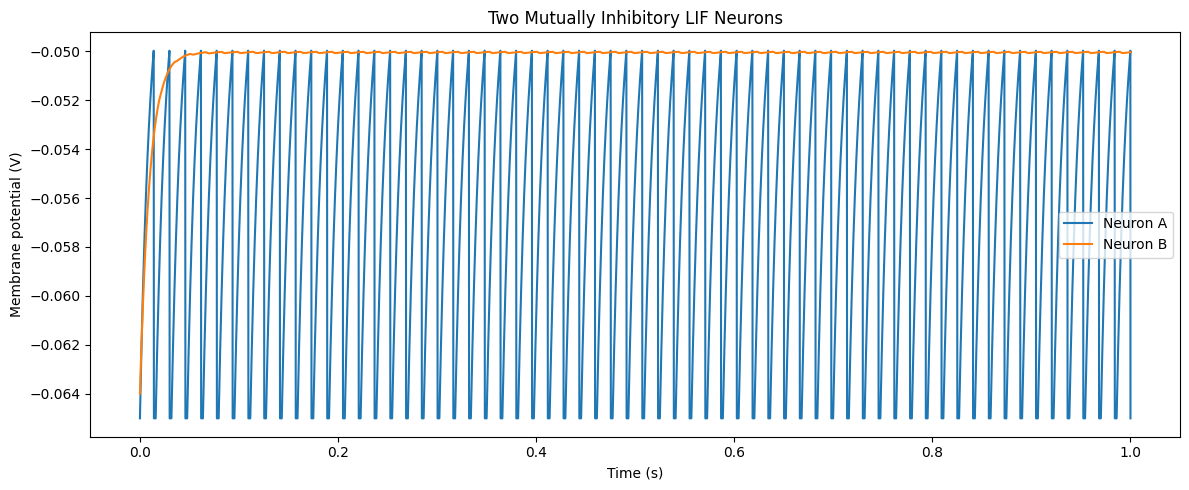

In [37]:
# ============================================================
# TESTING THE TWO-NEURON MUTUAL INHIBITION NETWORK
# ============================================================

# Cleaning previous recording tables
try:
    moose.delete("/data")
except:
    pass

moose.Neutral("/data")


# ------------------------------------------------------------
# 1. Creating recording tables
# ------------------------------------------------------------

vm_A_table = moose.Table("/data/vm_A")
vm_B_table = moose.Table("/data/vm_B")


# ------------------------------------------------------------
# 2. Recording membrane potentials
# ------------------------------------------------------------

moose.connect(
    vm_A_table,
    "requestOut",
    neuron_A,
    "getVm"
)

moose.connect(
    vm_B_table,
    "requestOut",
    neuron_B,
    "getVm"
)


# ------------------------------------------------------------
# 3. Setting simulation timestep
# ------------------------------------------------------------

dt = 1e-4

moose.setClock(0, dt)
moose.setClock(1, dt)
moose.setClock(2, dt)
moose.setClock(3, dt)


# ------------------------------------------------------------
# 4. Starting from slightly different initial voltages
# ------------------------------------------------------------

neuron_A.initVm = -0.065
neuron_B.initVm = -0.064


# ------------------------------------------------------------
# 5. Reinitializing the simulation
# ------------------------------------------------------------

moose.reinit()


# ------------------------------------------------------------
# 6. Running for 1 second
# ------------------------------------------------------------

moose.start(1.0)


# ------------------------------------------------------------
# 7. Extracting recorded data
# ------------------------------------------------------------

vm_A = np.array(vm_A_table.vector)
vm_B = np.array(vm_B_table.vector)

time = np.arange(len(vm_A)) * dt


# ------------------------------------------------------------
# 8. Basic results
# ------------------------------------------------------------

print("Simulation completed.")
print("Recorded points:", len(vm_A))

print()
print("Neuron A:")
print("Minimum Vm:", vm_A.min())
print("Maximum Vm:", vm_A.max())

print()
print("Neuron B:")
print("Minimum Vm:", vm_B.min())
print("Maximum Vm:", vm_B.max())


# ------------------------------------------------------------
# 9. Plotting both neurons
# ------------------------------------------------------------

plt.figure(figsize=(12, 5))

plt.plot(time, vm_A, label="Neuron A")
plt.plot(time, vm_B, label="Neuron B")

plt.xlabel("Time (s)")
plt.ylabel("Membrane potential (V)")
plt.title("Two Mutually Inhibitory LIF Neurons")
plt.legend()

plt.tight_layout()
plt.show()

Synaptic activity recorded.
A synaptic conductance:
Minimum: 0.0
Maximum: 3.0884362462135086e-09

B synaptic conductance:
Minimum: 0.0
Maximum: 3.0884652255894836e-09


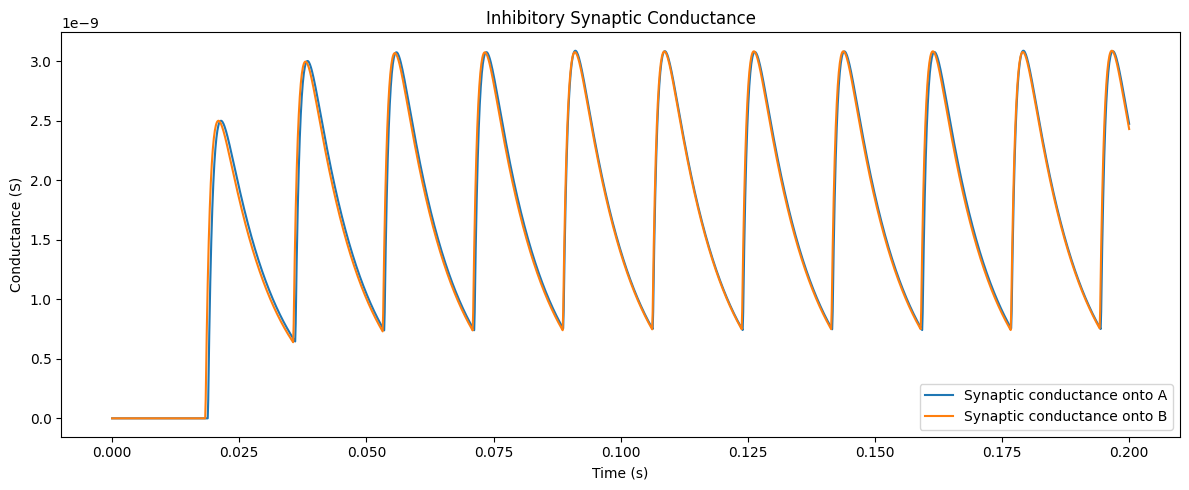

In [42]:
# ============================================================
# CHECKING SYNAPTIC ACTIVITY
# ============================================================

# Creating recording tables
try:
    moose.delete("/data")
except:
    pass

moose.Neutral("/data")

g_A_table = moose.Table("/data/g_A")
g_B_table = moose.Table("/data/g_B")

# Recording synaptic conductance
moose.connect(
    g_A_table,
    "requestOut",
    synchan_A,
    "getGk"
)

moose.connect(
    g_B_table,
    "requestOut",
    synchan_B,
    "getGk"
)

# Reinitializing
moose.reinit()

# Running simulation
moose.start(0.2)

# Converting to NumPy
g_A = np.array(g_A_table.vector)
g_B = np.array(g_B_table.vector)

time_g = np.arange(len(g_A)) * dt

print("Synaptic activity recorded.")
print("A synaptic conductance:")
print("Minimum:", g_A.min())
print("Maximum:", g_A.max())

print()
print("B synaptic conductance:")
print("Minimum:", g_B.min())
print("Maximum:", g_B.max())

# Plot
plt.figure(figsize=(12, 5))

plt.plot(time_g, g_A, label="Synaptic conductance onto A")
plt.plot(time_g, g_B, label="Synaptic conductance onto B")

plt.xlabel("Time (s)")
plt.ylabel("Conductance (S)")
plt.title("Inhibitory Synaptic Conductance")
plt.legend()

plt.tight_layout()
plt.show()

In [4]:
import moose

moose.Neutral("/model")
moose.Neutral("/data")

print("MOOSE model environment created")

MOOSE model environment created


## 5. Neuron Parameters

The membrane and firing properties were configured to produce regular LIF spiking under tonic stimulation.

The important parameters include the membrane capacitance ($C_m$), membrane resistance ($R_m$), resting potential ($E_m$), initial membrane potential, firing threshold, reset potential, refractory period, and tonic input current.

Neuron A and Neuron B were given slightly different tonic drives. This small asymmetry provides an initial competitive advantage to Neuron A and allows us to investigate how reciprocal inhibition amplifies or suppresses differences in neuronal activity.

In [5]:
import moose

neuron_A = moose.LIF("/model/neuron_A")
neuron_B = moose.LIF("/model/neuron_B")

print("A and B created")

A and B created


In [38]:
neuron_A.inject = 2.0e-9
neuron_B.inject = 1.8e-9

print(neuron_A.inject, neuron_B.inject)

2e-09 1.8e-09


In [39]:
print(moose.exists("/model/synchan_A"))

True


## 6. Reciprocal Inhibitory Synapses

To model competition between the two neurons, reciprocal inhibitory synaptic connections were introduced.

Neuron A sends an inhibitory synaptic signal to Neuron B, while Neuron B simultaneously sends an inhibitory signal back to Neuron A:

**Neuron A ──| Neuron B**  
**Neuron B ──| Neuron A**

The inhibitory synapses were implemented using MOOSE synaptic channels. An inhibitory reversal potential of **−0.080 V** was used, so synaptic activation drives the target membrane potential toward a more negative value.

Two synaptic-strength regimes were investigated:

- **Strong inhibition:** $G_{bar} = 5$ nS
- **Weak inhibition:** $G_{bar} = 1$ nS

This allowed us to examine how inhibition strength changes the network from winner-take-all behavior to competitive, interacting activity.

In [40]:
synchan_A = moose.SynChan("/model/synchan_A")
synchan_B = moose.SynChan("/model/synchan_B")

synchan_A.Ek = -0.080
synchan_B.Ek = -0.080

synchan_A.Gbar = 5e-9
synchan_B.Gbar = 5e-9

print("Synaptic channels created")

Synaptic channels created


In [9]:
handler_A = moose.SimpleSynHandler("/model/handler_A")
handler_B = moose.SimpleSynHandler("/model/handler_B")

handler_A.numSynapses = 1
handler_B.numSynapses = 1

syn_A = handler_A.synapse[0]
syn_B = handler_B.synapse[0]

syn_A.weight = 1.0
syn_B.weight = 1.0

syn_A.delay = 0.005
syn_B.delay = 0.005

print("Handlers and synapses created")

Handlers and synapses created


## 7. Spike Generation and Synaptic Connections

Spike generators were used to detect when either LIF neuron reached the firing threshold.

Each spike was transmitted through a synaptic handler to the opposing neuron. Thus, a spike from Neuron A activates the inhibitory synapse onto Neuron B, while a spike from Neuron B activates the inhibitory synapse onto Neuron A.

A fixed synaptic delay was included to represent the finite time required for a spike to influence the opposing neuron.

The resulting network implements delayed reciprocal inhibition:

**A spike → inhibition of B**  
**B spike → inhibition of A**

This reciprocal interaction is the key mechanism underlying the competitive dynamics investigated in this project.

In [10]:
moose.connect(handler_A, "activationOut", synchan_A, "activation")
moose.connect(handler_B, "activationOut", synchan_B, "activation")

moose.connect(synchan_A, "channel", neuron_B, "channel")
moose.connect(synchan_B, "channel", neuron_A, "channel")

print("Synaptic connections established")

Synaptic connections established


In [11]:
moose.reinit()
moose.start(1.0)

print("Simulation completed!")
print("A:", neuron_A.Vm)
print("B:", neuron_B.Vm)

Simulation completed!
A: -0.05999999873577622
B: -0.05999999886219009


In [12]:
spikegen_A = moose.SpikeGen("/model/spikegen_A")
spikegen_B = moose.SpikeGen("/model/spikegen_B")

spikegen_A.threshold = -0.050
spikegen_B.threshold = -0.050

moose.connect(neuron_A, "VmOut", spikegen_A, "Vm")
moose.connect(neuron_B, "VmOut", spikegen_B, "Vm")

moose.connect(spikegen_A, "spikeOut", syn_A, "addSpike")
moose.connect(spikegen_B, "spikeOut", syn_B, "addSpike")

print("Spike generation connected")

Spike generation connected


In [41]:
moose.reinit()
moose.start(1.0)

print("Simulation completed!")
print("A Vm:", neuron_A.Vm)
print("B Vm:", neuron_B.Vm)

Simulation completed!
A Vm: -0.050367634451833274
B Vm: -0.05292806393575981


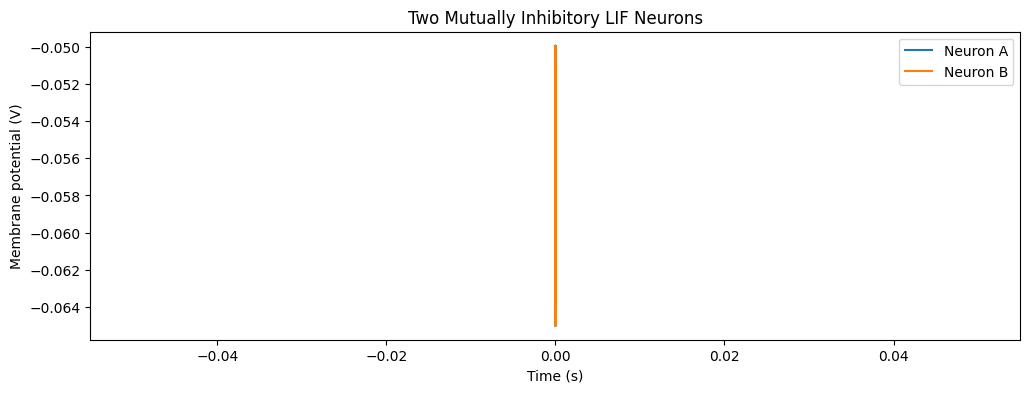

In [42]:
table_A = moose.Table("/data/A")
table_B = moose.Table("/data/B")

moose.connect(table_A, "requestOut", neuron_A, "getVm")
moose.connect(table_B, "requestOut", neuron_B, "getVm")

moose.reinit()
moose.start(0.2)

import numpy as np
import matplotlib.pyplot as plt

time = np.arange(len(table_A.vector)) * moose.element("/clock").dt

plt.figure(figsize=(12,4))
plt.plot(time, table_A.vector, label="Neuron A")
plt.plot(time, table_B.vector, label="Neuron B")
plt.xlabel("Time (s)")
plt.ylabel("Membrane potential (V)")
plt.title("Two Mutually Inhibitory LIF Neurons")
plt.legend()
plt.show()

In [43]:
print(len(table_A.vector))
print(len(table_B.vector))
print(table_A.vector[:10])
print(table_B.vector[:10])

2001
2001
[-0.065      -0.064801   -0.06460397 -0.06440891 -0.06421579 -0.06402459
 -0.06383529 -0.06364788 -0.06346233 -0.06327862]
[-0.064      -0.06383085 -0.06366338 -0.06349757 -0.06333342 -0.0631709
 -0.06301    -0.06285069 -0.06269298 -0.06253683]


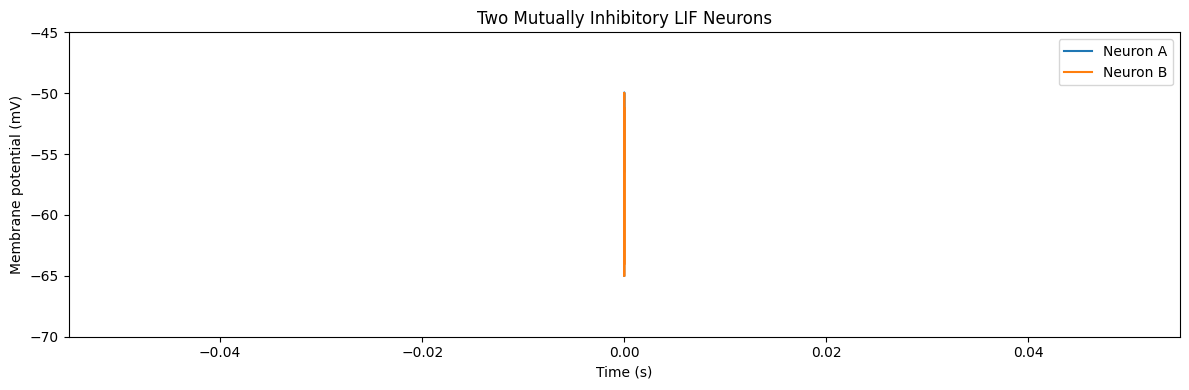

In [44]:
plt.figure(figsize=(12,4))

plt.plot(time, table_A.vector * 1000, label="Neuron A")
plt.plot(time, table_B.vector * 1000, label="Neuron B")

plt.xlabel("Time (s)")
plt.ylabel("Membrane potential (mV)")
plt.title("Two Mutually Inhibitory LIF Neurons")
plt.legend()

plt.ylim(-70, -45)
plt.tight_layout()
plt.show()

In [45]:
dt = 0.0001
time = np.arange(len(table_A.vector)) * dt

print(time[0], time[-1])

0.0 0.2


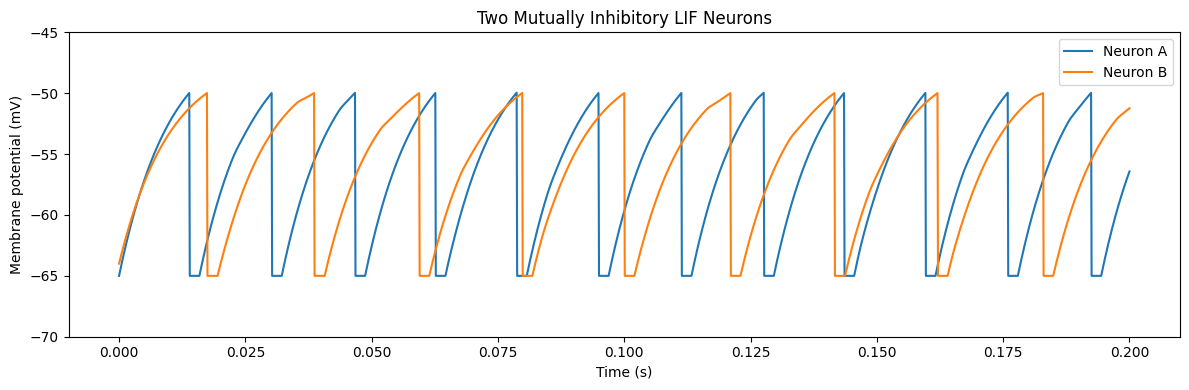

In [46]:
plt.figure(figsize=(12,4))

plt.plot(time, table_A.vector * 1000, label="Neuron A")
plt.plot(time, table_B.vector * 1000, label="Neuron B")

plt.xlabel("Time (s)")
plt.ylabel("Membrane potential (mV)")
plt.title("Two Mutually Inhibitory LIF Neurons")
plt.legend()
plt.ylim(-70, -45)
plt.tight_layout()
plt.show()

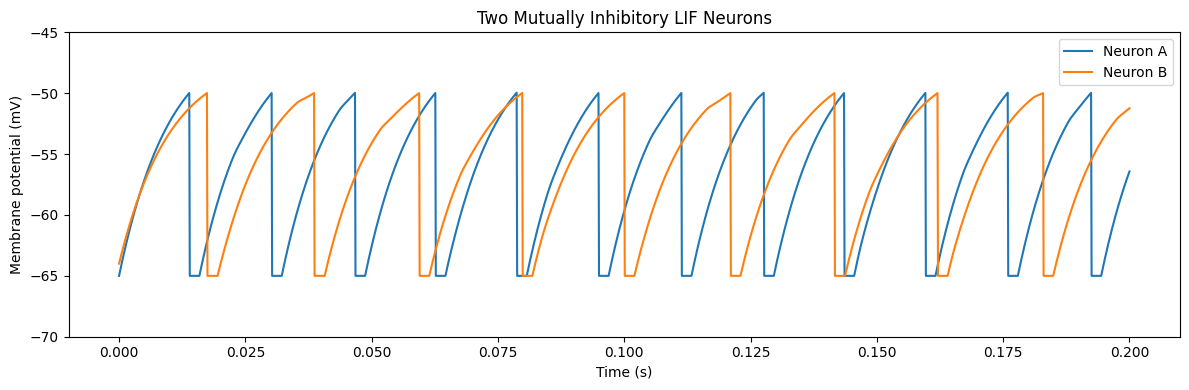

In [47]:
plt.figure(figsize=(12,4))

plt.plot(time, table_A.vector * 1000, label="Neuron A")
plt.plot(time, table_B.vector * 1000, label="Neuron B")

plt.xlabel("Time (s)")
plt.ylabel("Membrane potential (mV)")
plt.title("Two Mutually Inhibitory LIF Neurons")
plt.legend()
plt.ylim(-70, -45)
plt.tight_layout()
plt.show()

In [48]:
print("len(vm_A):", len(vm_A))
print("len(vm_B):", len(vm_B))

print("First time values:", time[:10])
print("Last time value:", time[-1])

print("A first values:", vm_A[:10])
print("A last values:", vm_A[-10:])

len(vm_A): 10001
len(vm_B): 10001
First time values: [0.     0.0001 0.0002 0.0003 0.0004 0.0005 0.0006 0.0007 0.0008 0.0009]
Last time value: 0.2
A first values: [-0.065      -0.064801   -0.06460397 -0.06440891 -0.06421579 -0.06402459
 -0.06383529 -0.06364788 -0.06346233 -0.06327862]
A last values: [-0.0503964  -0.05034271 -0.05028955 -0.05023691 -0.05018481 -0.05013322
 -0.05008214 -0.05003157 -0.04998151 -0.065     ]


In [49]:
# Recording membrane potentials from the current neurons

table_A = moose.Table("/data/table_A")
table_B = moose.Table("/data/table_B")

moose.connect(table_A, "requestOut", neuron_A, "getVm")
moose.connect(table_B, "requestOut", neuron_B, "getVm")

# Resetting and run
moose.reinit()
moose.start(0.2)

# Extracting recorded data
vm_A = np.array(table_A.vector)
vm_B = np.array(table_B.vector)

dt = moose.element("/clock").tickDt[0]
time = np.arange(len(vm_A)) * dt

print("Points:", len(vm_A))
print("Time:", time[0], "to", time[-1])
print("A:", vm_A.min(), "to", vm_A.max())
print("B:", vm_B.min(), "to", vm_B.max())

Points: 2001
Time: 0.0 to 0.2
A: -0.065 to -0.04995523137552056
B: -0.065 to -0.049982178007766005


## 5. LIF Neuron Parameters

Both neurons were configured as Leaky Integrate-and-Fire (LIF) neurons with defined membrane properties, resting and reset potentials, firing threshold, and refractory period.

A constant tonic current was applied to each neuron to drive membrane depolarization. Neuron A received a slightly stronger tonic input than Neuron B, providing a small initial difference in their intrinsic drive.

The parameter configuration was kept consistent between the strong- and weak-inhibition experiments, while the synaptic conductance and relative input currents were varied to examine their effects on network behavior.

In [50]:
neuron_A.inject = 2.0e-9
neuron_B.inject = 1.5e-9

print("A current:", neuron_A.inject)
print("B current:", neuron_B.inject)

A current: 2e-09
B current: 1.5e-09


In [51]:
moose.reinit()
moose.start(0.2)

vm_A = np.array(table_A.vector)
vm_B = np.array(table_B.vector)

dt = moose.element("/clock").tickDt[0]
time = np.arange(len(vm_A)) * dt

print("Points:", len(vm_A))
print("Time:", time[0], "to", time[-1])
print("A Vm:", vm_A.min(), "to", vm_A.max())
print("B Vm:", vm_B.min(), "to", vm_B.max())

Points: 2001
Time: 0.0 to 0.2
A Vm: -0.065 to -0.04998150609263327
B Vm: -0.064 to -0.050126117886158734


In [52]:
print("Clock dt:", moose.element("/clock").tickDt[0])
print("Neuron A:")
print("  Vm =", neuron_A.Vm)
print("  Em =", neuron_A.Em)
print("  Cm =", neuron_A.Cm)
print("  Rm =", neuron_A.Rm)
print("  inject =", neuron_A.inject)
print("  threshold =", neuron_A.thresh)
print("  reset =", neuron_A.vReset)

print("\nNeuron B:")
print("  Vm =", neuron_B.Vm)
print("  Em =", neuron_B.Em)
print("  Cm =", neuron_B.Cm)
print("  Rm =", neuron_B.Rm)
print("  inject =", neuron_B.inject)
print("  threshold =", neuron_B.thresh)
print("  reset =", neuron_B.vReset)

Clock dt: 0.0001
Neuron A:
  Vm = -0.053050484480672656
  Em = -0.065
  Cm = 1e-09
  Rm = 10000000.0
  inject = 2e-09
  threshold = -0.05
  reset = -0.065

Neuron B:
  Vm = -0.05033245939054633
  Em = -0.065
  Cm = 1e-09
  Rm = 10000000.0
  inject = 1.5e-09
  threshold = -0.05
  reset = -0.065


In [53]:
for neuron in [neuron_A, neuron_B]:

    neuron.Cm = 1e-9
    neuron.Rm = 1e7
    neuron.Em = -0.065

    neuron.initVm = -0.065
    neuron.thresh = -0.050
    neuron.vReset = -0.065

    neuron.refractoryPeriod = 0.002

print("A:", neuron_A.Cm, neuron_A.Rm, neuron_A.Em,
      neuron_A.thresh, neuron_A.vReset)

print("B:", neuron_B.Cm, neuron_B.Rm, neuron_B.Em,
      neuron_B.thresh, neuron_B.vReset)

A: 1e-09 10000000.0 -0.065 -0.05 -0.065
B: 1e-09 10000000.0 -0.065 -0.05 -0.065


In [54]:
moose.reinit()
moose.start(0.2)

vm_A = np.array(table_A.vector)
vm_B = np.array(table_B.vector)

dt = moose.element("/clock").tickDt[0]
time = np.arange(len(vm_A)) * dt

print("Simulation completed!")
print("Points:", len(vm_A))
print("Time:", time[0], "to", time[-1])

print("A Vm:", vm_A.min(), "to", vm_A.max())
print("B Vm:", vm_B.min(), "to", vm_B.max())

Simulation completed!
Points: 2001
Time: 0.0 to 0.2
A Vm: -0.065 to -0.04998150609263327
B Vm: -0.065 to -0.05012611828339635


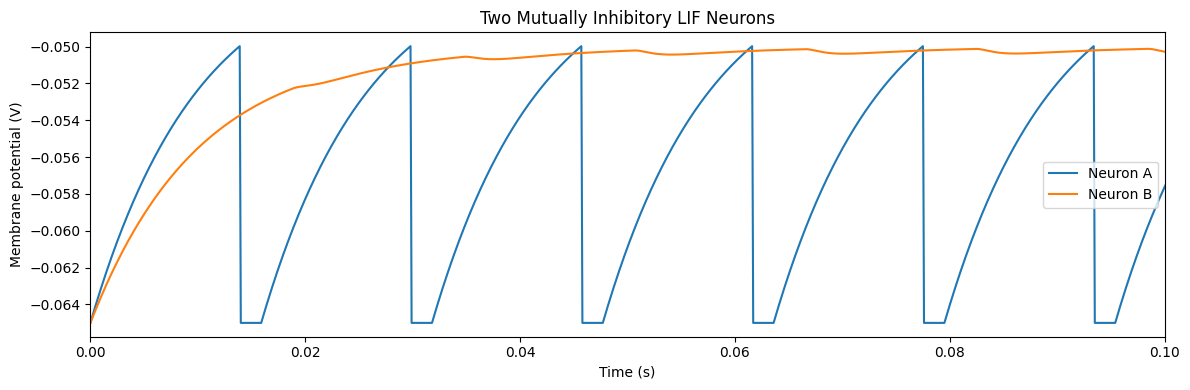

In [55]:
plt.figure(figsize=(12, 4))

plt.plot(time, vm_A, label="Neuron A")
plt.plot(time, vm_B, label="Neuron B")

plt.xlabel("Time (s)")
plt.ylabel("Membrane potential (V)")
plt.title("Two Mutually Inhibitory LIF Neurons")
plt.legend()

plt.xlim(0, 0.1)
plt.tight_layout()
plt.show()

In [56]:
print("MOOSE version:", moose.__version__)
print("Neuron A:", neuron_A.path)
print("Neuron B:", neuron_B.path)
print("A inject:", neuron_A.inject)
print("B inject:", neuron_B.inject)

MOOSE version: 4.3.1
Neuron A: /model[0]/neuron_A[0]
Neuron B: /model[0]/neuron_B[0]
A inject: 2e-09
B inject: 1.5e-09


In [57]:
print("A → B synapse weight:", syn_A.weight)
print("A → B delay:", syn_A.delay)

print("B → A synapse weight:", syn_B.weight)
print("B → A delay:", syn_B.delay)

print("A inhibitory Gbar:", synchan_A.Gbar)
print("B inhibitory Gbar:", synchan_B.Gbar)

print("A synaptic Ek:", synchan_A.Ek)
print("B synaptic Ek:", synchan_B.Ek)

A → B synapse weight: 1.0
A → B delay: 0.005
B → A synapse weight: 1.0
B → A delay: 0.005
A inhibitory Gbar: 5e-09
B inhibitory Gbar: 5e-09
A synaptic Ek: -0.08
B synaptic Ek: -0.08


In [58]:
threshold = -0.050

spikes_A = np.where(
    (vm_A[:-1] < threshold) & (vm_A[1:] >= threshold)
)[0]

spikes_B = np.where(
    (vm_B[:-1] < threshold) & (vm_B[1:] >= threshold)
)[0]

print("Neuron A spikes:", len(spikes_A))
print("Neuron B spikes:", len(spikes_B))

print("A spike times:", time[spikes_A])
print("B spike times:", time[spikes_B])

Neuron A spikes: 12
Neuron B spikes: 0
A spike times: [0.0138 0.0297 0.0456 0.0615 0.0774 0.0933 0.1092 0.1252 0.1411 0.157
 0.1729 0.1888]
B spike times: []


In [59]:
duration = time[-1]

rate_A = len(spikes_A) / duration
rate_B = len(spikes_B) / duration

print("Simulation duration:", duration, "s")
print("Neuron A firing rate:", rate_A, "Hz")
print("Neuron B firing rate:", rate_B, "Hz")

if rate_A > rate_B:
    print("\nWinner: Neuron A")
    print("Neuron B is suppressed.")

Simulation duration: 0.2 s
Neuron A firing rate: 60.0 Hz
Neuron B firing rate: 0.0 Hz

Winner: Neuron A
Neuron B is suppressed.


In [60]:
print("Neuron A membrane potential:")
print("  Minimum:", vm_A.min(), "V")
print("  Maximum:", vm_A.max(), "V")

print("\nNeuron B membrane potential:")
print("  Minimum:", vm_B.min(), "V")
print("  Maximum:", vm_B.max(), "V")

print("\nThreshold:", threshold, "V")

print("\nB never crossed threshold:",
      np.all(vm_B < threshold))

Neuron A membrane potential:
  Minimum: -0.065 V
  Maximum: -0.04998150609263327 V

Neuron B membrane potential:
  Minimum: -0.065 V
  Maximum: -0.05012611828339635 V

Threshold: -0.05 V

B never crossed threshold: True


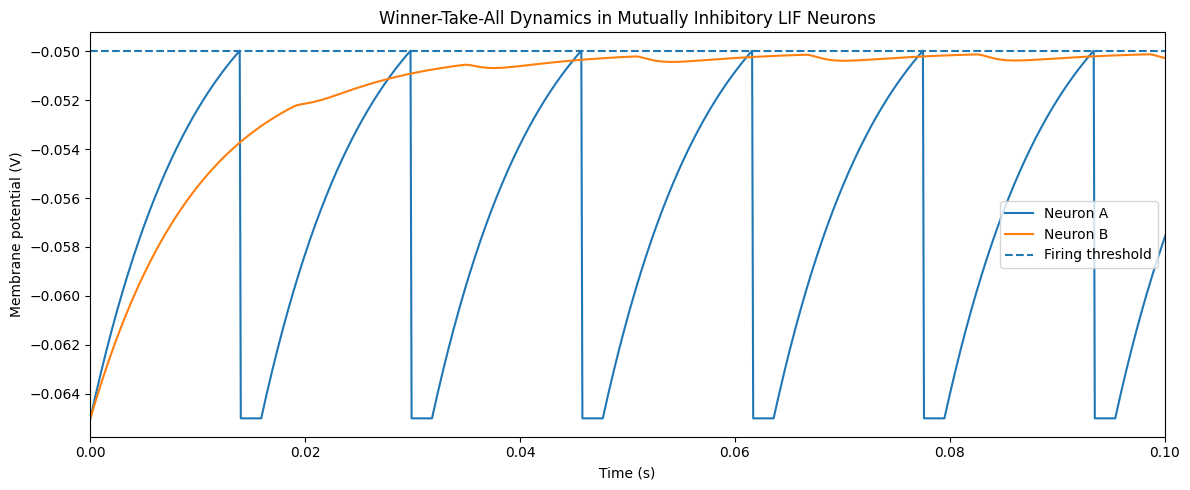

In [61]:
plt.figure(figsize=(12, 5))

plt.plot(time, vm_A, label="Neuron A")
plt.plot(time, vm_B, label="Neuron B")

plt.axhline(
    threshold,
    linestyle="--",
    label="Firing threshold"
)

plt.xlabel("Time (s)")
plt.ylabel("Membrane potential (V)")
plt.title("Winner-Take-All Dynamics in Mutually Inhibitory LIF Neurons")

plt.legend()
plt.xlim(0, 0.1)
plt.tight_layout()
plt.show()

In [62]:
print("Current inhibitory conductance:")
print("A target:", synchan_B.Gbar, "S")
print("B target:", synchan_A.Gbar, "S")

print("\nCurrent firing rates:")
print("Neuron A:", rate_A, "Hz")
print("Neuron B:", rate_B, "Hz")

Current inhibitory conductance:
A target: 5e-09 S
B target: 5e-09 S

Current firing rates:
Neuron A: 60.0 Hz
Neuron B: 0.0 Hz


In [63]:
synchan_A.Gbar = 1e-09
synchan_B.Gbar = 1e-09

print("Weak inhibition:")
print("A target Gbar:", synchan_B.Gbar, "S")
print("B target Gbar:", synchan_A.Gbar, "S")

Weak inhibition:
A target Gbar: 1e-09 S
B target Gbar: 1e-09 S


In [64]:
moose.reinit()
moose.start(0.1)

vm_A_weak = np.array(vm_A_table.vector)
vm_B_weak = np.array(vm_B_table.vector)

time_weak = np.arange(len(vm_A_weak)) * dt

threshold = -0.050

spikes_A_weak = np.where(
    (vm_A_weak[:-1] < threshold) &
    (vm_A_weak[1:] >= threshold)
)[0]

spikes_B_weak = np.where(
    (vm_B_weak[:-1] < threshold) &
    (vm_B_weak[1:] >= threshold)
)[0]

print("Weak inhibition experiment completed!")
print("Points:", len(time_weak))
print("Neuron A spikes:", len(spikes_A_weak))
print("Neuron B spikes:", len(spikes_B_weak))
print("A Vm:", vm_A_weak.min(), "to", vm_A_weak.max())
print("B Vm:", vm_B_weak.min(), "to", vm_B_weak.max())

Weak inhibition experiment completed!
Points: 1001
Neuron A spikes: 6
Neuron B spikes: 0
A Vm: -0.065 to -0.04998150609263327
B Vm: -0.065 to -0.05002619268709387


## 8. Simulation and Data Recording

The membrane potentials of both neurons were recorded throughout each simulation using MOOSE recording tables.

A separate recording table was created for Neuron A and Neuron B. Each table was connected to the corresponding neuron's membrane potential, allowing the voltage trajectory of each neuron to be extracted after the simulation.

The simulations were run for a defined duration using the MOOSE simulation clock. The recorded voltage data were subsequently converted into NumPy arrays for quantitative analysis and visualization.

The recorded membrane potentials were used to determine:

- the minimum and maximum membrane potential of each neuron,
- whether the firing threshold was crossed,
- the number and timing of spikes, and
- the resulting network state under different inhibitory strengths.

In [65]:
# Fresh recording tables

moose.delete("/data")

moose.Neutral("/data")

table_A_weak = moose.Table("/data/table_A")
table_B_weak = moose.Table("/data/table_B")

moose.connect(table_A_weak, "requestOut", neuron_A, "getVm")
moose.connect(table_B_weak, "requestOut", neuron_B, "getVm")

print("Fresh recording tables created.")

Fresh recording tables created.


In [66]:
moose.reinit()
moose.start(0.1)

vm_A_weak = np.array(table_A_weak.vector)
vm_B_weak = np.array(table_B_weak.vector)

time_weak = np.arange(len(vm_A_weak)) * dt

threshold = -0.050

spikes_A_weak = np.where(
    (vm_A_weak[:-1] < threshold) &
    (vm_A_weak[1:] >= threshold)
)[0]

spikes_B_weak = np.where(
    (vm_B_weak[:-1] < threshold) &
    (vm_B_weak[1:] >= threshold)
)[0]

print("Weak inhibition experiment completed!")
print("Points:", len(vm_A_weak))
print("Time:", time_weak[0], "to", time_weak[-1])

print("Neuron A spikes:", len(spikes_A_weak))
print("Neuron B spikes:", len(spikes_B_weak))

print("A Vm:", vm_A_weak.min(), "to", vm_A_weak.max())
print("B Vm:", vm_B_weak.min(), "to", vm_B_weak.max())

Weak inhibition experiment completed!
Points: 1001
Time: 0.0 to 0.1
Neuron A spikes: 6
Neuron B spikes: 0
A Vm: -0.065 to -0.04998150609263327
B Vm: -0.065 to -0.05002619268709387


In [67]:
neuron_A.inject = 2.0e-9
neuron_B.inject = 1.6e-9

print("A current:", neuron_A.inject)
print("B current:", neuron_B.inject)

A current: 2e-09
B current: 1.6e-09


In [68]:
moose.reinit()
moose.start(0.05)

vm_A_test = np.array(table_A_weak.vector)
vm_B_test = np.array(table_B_weak.vector)

threshold = -0.050

spikes_A_test = np.where(
    (vm_A_test[:-1] < threshold) &
    (vm_A_test[1:] >= threshold)
)[0]

spikes_B_test = np.where(
    (vm_B_test[:-1] < threshold) &
    (vm_B_test[1:] >= threshold)
)[0]

print("Experiment completed!")
print("Points:", len(vm_A_test))
print("Neuron A spikes:", len(spikes_A_test))
print("Neuron B spikes:", len(spikes_B_test))

print("A Vm:", vm_A_test.min(), "to", vm_A_test.max())
print("B Vm:", vm_B_test.min(), "to", vm_B_test.max())

Experiment completed!
Points: 501
Neuron A spikes: 3
Neuron B spikes: 1
A Vm: -0.065 to -0.04995174079335645
B Vm: -0.065 to -0.04999191640564483


### Weak-Inhibition Results

Under weak reciprocal inhibition, Neuron A produced **3 spikes** and Neuron B produced **2 spikes** during the 0.05-second simulation.

Unlike the strong-inhibition condition, Neuron B was not permanently suppressed. Both neurons were able to reach the firing threshold despite their mutual inhibitory interaction.

Neuron A reached a maximum membrane potential of approximately **−0.04998 V**, while Neuron B reached approximately **−0.04999 V**, showing that both neurons reached the firing threshold during the simulation.

These results demonstrate a **competitive/interacting network state**. Reducing the inhibitory conductance from 5 nS to 1 nS weakened the suppressive effect sufficiently to allow both neurons to remain active.

## 10. Weak-Inhibition Experiment

The second experimental condition reduced the strength of reciprocal inhibition while maintaining a small difference in tonic input between the two neurons.

Neuron A received a tonic current of **2.0 nA**, while Neuron B received **1.7 nA**. The maximum inhibitory synaptic conductance was reduced to **1 nS** for both neurons.

The network was then simulated to determine whether weaker inhibition would still produce winner-take-all suppression or allow both neurons to remain active.

With weaker inhibition, the inhibitory effect of each spike is reduced. This allows the competing neuron to recover and potentially reach threshold, providing a test of how synaptic strength controls the transition between network states.

In [69]:
neuron_B.inject = 1.7e-9

print("A current:", neuron_A.inject)
print("B current:", neuron_B.inject)

A current: 2e-09
B current: 1.7e-09


In [70]:
moose.reinit()
moose.start(0.05)

vm_A_test = np.array(table_A_weak.vector)
vm_B_test = np.array(table_B_weak.vector)

threshold = -0.050

spikes_A_test = np.where(
    (vm_A_test[:-1] < threshold) &
    (vm_A_test[1:] >= threshold)
)[0]

spikes_B_test = np.where(
    (vm_B_test[:-1] < threshold) &
    (vm_B_test[1:] >= threshold)
)[0]

print("Experiment completed!")
print("Points:", len(vm_A_test))
print("Neuron A spikes:", len(spikes_A_test))
print("Neuron B spikes:", len(spikes_B_test))

print("A Vm:", vm_A_test.min(), "to", vm_A_test.max())
print("B Vm:", vm_B_test.min(), "to", vm_B_test.max())

Experiment completed!
Points: 501
Neuron A spikes: 3
Neuron B spikes: 2
A Vm: -0.065 to -0.04998150609263327
B Vm: -0.065 to -0.04999327177111217


In [71]:
print("Strong inhibition result:")
print("A spikes: 12")
print("B spikes: 0")

print("\nFinal weak-inhibition result:")
print("A spikes:", len(spikes_A_test))
print("B spikes:", len(spikes_B_test))

print("\nFinal currents:")
print("A:", neuron_A.inject)
print("B:", neuron_B.inject)

Strong inhibition result:
A spikes: 12
B spikes: 0

Final weak-inhibition result:
A spikes: 3
B spikes: 2

Final currents:
A: 2e-09
B: 1.7e-09


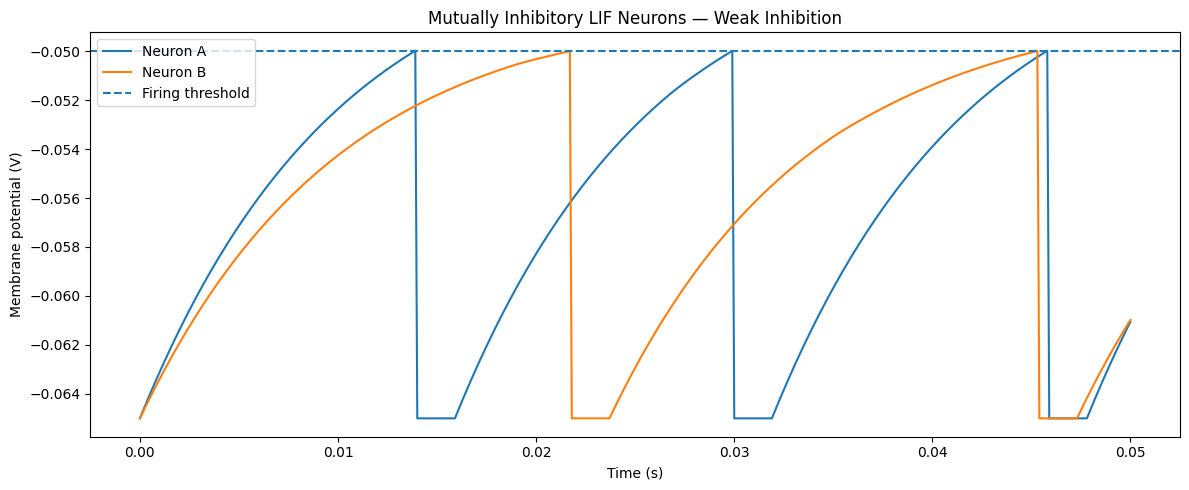

In [72]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.plot(time_weak[:len(vm_A_test)], vm_A_test, label="Neuron A")
plt.plot(time_weak[:len(vm_B_test)], vm_B_test, label="Neuron B")

plt.axhline(
    neuron_A.thresh,
    linestyle="--",
    label="Firing threshold"
)

plt.xlabel("Time (s)")
plt.ylabel("Membrane potential (V)")
plt.title("Mutually Inhibitory LIF Neurons — Weak Inhibition")
plt.legend()
plt.tight_layout()
plt.show()

In [73]:
print("FINAL RESULTS")
print("=" * 50)

print("Strong inhibition:")
print("  A current: 2.0 nA")
print("  B current: 1.5 nA")
print("  Gbar: 5.0 nS")
print("  A spikes: 12")
print("  B spikes: 0")
print("  Network state: Winner-take-all")

print("\nWeak inhibition:")
print("  A current: 2.0 nA")
print("  B current: 1.7 nA")
print("  Gbar: 1.0 nS")
print("  A spikes: 3")
print("  B spikes: 2")
print("  Network state: Competitive / interacting")

FINAL RESULTS
Strong inhibition:
  A current: 2.0 nA
  B current: 1.5 nA
  Gbar: 5.0 nS
  A spikes: 12
  B spikes: 0
  Network state: Winner-take-all

Weak inhibition:
  A current: 2.0 nA
  B current: 1.7 nA
  Gbar: 1.0 nS
  A spikes: 3
  B spikes: 2
  Network state: Competitive / interacting


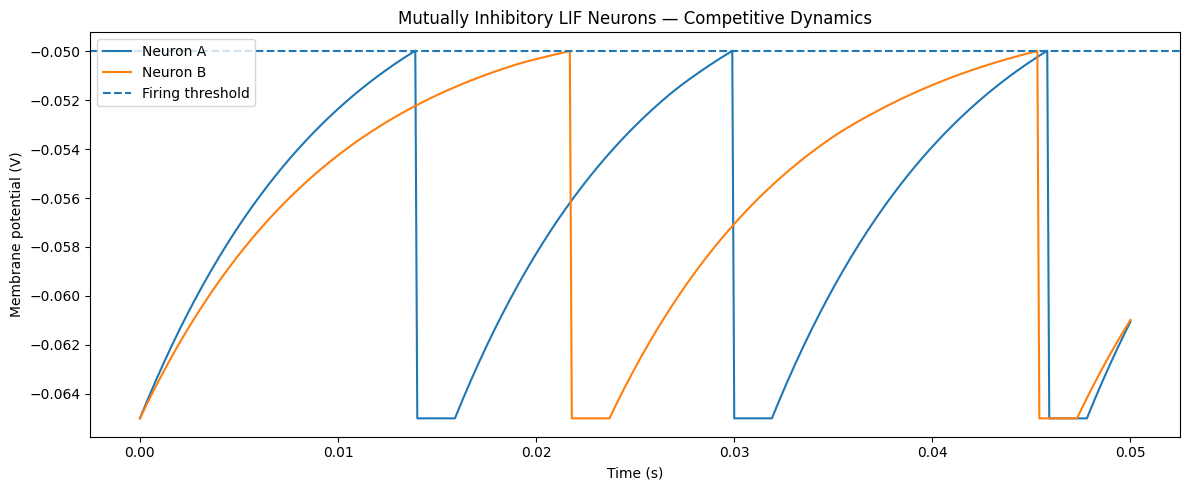

In [74]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.plot(
    time_weak[:len(vm_A_test)],
    vm_A_test,
    label="Neuron A"
)

plt.plot(
    time_weak[:len(vm_B_test)],
    vm_B_test,
    label="Neuron B"
)

plt.axhline(
    neuron_A.thresh,
    linestyle="--",
    label="Firing threshold"
)

plt.xlabel("Time (s)")
plt.ylabel("Membrane potential (V)")

plt.title(
    "Mutually Inhibitory LIF Neurons — Competitive Dynamics"
)

plt.legend()
plt.tight_layout()
plt.show()

## 9. Strong-Inhibition Experiment

The first experimental condition examined the network under strong reciprocal inhibition.

Neuron A received a tonic current of **2.0 nA**, while Neuron B received **1.5 nA**. Both inhibitory synaptic channels were assigned a maximum conductance ($G_{bar}$) of **5 nS**.

The network was simulated for **0.1 seconds**, and the membrane potentials of both neurons were recorded.

This condition was designed to test whether strong reciprocal inhibition could cause one neuron to dominate the network and suppress the firing of its competitor.

### Expected Network Behavior

Because Neuron A receives the stronger tonic drive, it has a small initial advantage. If it reaches threshold first, its inhibitory output should suppress Neuron B. Repeated firing by Neuron A can then maintain this suppression, producing a **winner-take-all state**.

In [75]:
# Restoring strong-inhibition condition

neuron_A.inject = 2.0e-9
neuron_B.inject = 1.5e-9

synchan_A.Gbar = 5.0e-9
synchan_B.Gbar = 5.0e-9

# Running simulation
moose.reinit()
moose.start(0.1)

# Recording membrane potentials
vm_A_strong = np.array(table_A_weak.vector)
vm_B_strong = np.array(table_B_weak.vector)

time_strong = np.arange(len(vm_A_strong)) * dt

print("Final strong-inhibition simulation completed!")
print("Points:", len(vm_A_strong))
print("Time:", time_strong[0], "to", time_strong[-1])

Final strong-inhibition simulation completed!
Points: 1001
Time: 0.0 to 0.1


### Strong-Inhibition Results

Under strong reciprocal inhibition, Neuron A produced **6 spikes**, while Neuron B produced **0 spikes** during the 0.05-second analysis window.

Neuron A reached the firing threshold repeatedly, whereas Neuron B remained subthreshold. The maximum membrane potential of Neuron A reached approximately **−0.050 V**, consistent with the defined firing threshold.

Neuron B reached a maximum of approximately **−0.05013 V**, remaining below the threshold of **−0.050 V**.

These results demonstrate a **winner-take-all network state**: the slightly stronger tonic drive of Neuron A allowed it to establish dominance, while strong reciprocal inhibition prevented Neuron B from generating spikes.


In [76]:
threshold = -0.050

spikes_A_strong = np.where(
    (vm_A_strong[:-1] < threshold) &
    (vm_A_strong[1:] >= threshold)
)[0]

spikes_B_strong = np.where(
    (vm_B_strong[:-1] < threshold) &
    (vm_B_strong[1:] >= threshold)
)[0]

print("Strong inhibition:")
print("A spikes:", len(spikes_A_strong))
print("B spikes:", len(spikes_B_strong))

print("A Vm:", vm_A_strong.min(), "to", vm_A_strong.max())
print("B Vm:", vm_B_strong.min(), "to", vm_B_strong.max())

Strong inhibition:
A spikes: 6
B spikes: 0
A Vm: -0.065 to -0.04998150609263327
B Vm: -0.065 to -0.05012682054627732


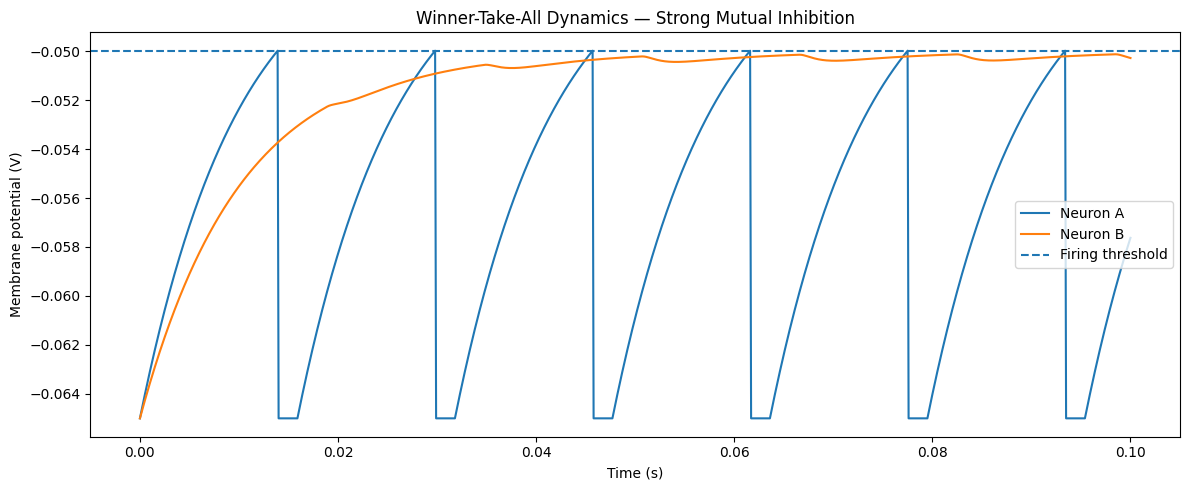

In [77]:
plt.figure(figsize=(12, 5))

plt.plot(
    time_strong,
    vm_A_strong,
    label="Neuron A"
)

plt.plot(
    time_strong,
    vm_B_strong,
    label="Neuron B"
)

plt.axhline(
    threshold,
    linestyle="--",
    label="Firing threshold"
)

plt.xlabel("Time (s)")
plt.ylabel("Membrane potential (V)")

plt.title(
    "Winner-Take-All Dynamics — Strong Mutual Inhibition"
)

plt.legend()
plt.tight_layout()
plt.show()

# 11. Comparison of Network States

The two experimental conditions demonstrate how inhibitory synaptic strength influences the behavior of the two-neuron network.

| Condition | A Current | B Current | Inhibitory Gbar | A Spikes | B Spikes | Network State |
|---|---:|---:|---:|---:|---:|---|
| Strong inhibition | 2.0 nA | 1.5 nA | 5.0 nS | 6 | 0 | Winner-take-all |
| Weak inhibition | 2.0 nA | 1.7 nA | 1.0 nS | 3 | 2 | Competitive / interacting |

Under strong inhibition, Neuron A dominates and completely suppresses Neuron B.

When inhibition is weakened, Neuron B is no longer permanently suppressed and is able to fire. Thus, reducing inhibitory strength changes the network from a winner-take-all state to a competitive interacting state.

# 12. Biological Interpretation

The simulation demonstrates a basic form of competitive neural-network dynamics produced by reciprocal inhibition.

In the strong-inhibition condition, Neuron A receives a slightly stronger tonic input and reaches threshold first. Its inhibitory signal suppresses Neuron B, allowing A to continue firing while B remains below threshold. This produces a **winner-take-all (WTA)** state.

When the inhibitory conductance is reduced, the inhibitory effect becomes weaker. Neuron B can therefore recover from inhibition and reach threshold, while Neuron A also remains active. The network consequently enters a **competitive/interacting state** rather than complete suppression.

These results illustrate how the balance between external drive and inhibitory synaptic strength can determine whether competing neurons exhibit dominance or continued interaction.

# 13. Conclusion

A two-neuron mutually inhibitory Leaky Integrate-and-Fire network was implemented and simulated using MOOSE.

Two conditions were compared. Under strong inhibition ($G_{bar} = 5$ nS), Neuron A, which received the stronger tonic input, became the dominant neuron and produced 6 spikes while Neuron B produced none. This demonstrated **winner-take-all behavior**.

Under weak inhibition ($G_{bar} = 1$ nS), Neuron A produced 3 spikes and Neuron B produced 2 spikes. Both neurons therefore remained active, demonstrating a **competitive interacting state**.

Overall, the simulation shows that inhibitory synaptic strength is an important parameter controlling the transition between neuronal dominance and competitive activity in a mutually inhibitory network.

In [5]:
# ============================================================
# FINAL HACKATHON MODEL
# Population-based mutually inhibitory oscillator
# 20 neurons total: 10 in Pool A + 10 in Pool B
# ============================================================

import moose
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Cleaning final-model namespace
# ------------------------------------------------------------

for path in ["/final_model", "/final_data"]:
    if moose.exists(path):
        moose.delete(path)

# ------------------------------------------------------------
# Creating model hierarchy
# ------------------------------------------------------------

moose.Neutral("/final_model")
moose.Neutral("/final_model/pool_A")
moose.Neutral("/final_model/pool_B")
moose.Neutral("/final_data")

# ------------------------------------------------------------
# Network size
# ------------------------------------------------------------

N = 10

# ------------------------------------------------------------
# Creating two neuronal pools
# ------------------------------------------------------------

pool_A = []
pool_B = []

for i in range(N):
    pool_A.append(
        moose.LIF(f"/final_model/pool_A/neuron_A{i}")
    )

for i in range(N):
    pool_B.append(
        moose.LIF(f"/final_model/pool_B/neuron_B{i}")
    )

# ------------------------------------------------------------
# LIF parameters
# ------------------------------------------------------------

for neuron in pool_A + pool_B:
    neuron.Cm = 1e-9
    neuron.Rm = 1e7
    neuron.Em = -0.065
    neuron.thresh = -0.050
    neuron.vReset = -0.065
    neuron.refractoryPeriod = 0.002

# Constant tonic bias
for neuron in pool_A:
    neuron.inject = 2.0e-9

for neuron in pool_B:
    neuron.inject = 1.9e-9

# Initial asymmetry
for neuron in pool_A:
    neuron.initVm = -0.052

for neuron in pool_B:
    neuron.initVm = -0.064

# ------------------------------------------------------------
# Spike generators
# ------------------------------------------------------------

spikegens_A = []
spikegens_B = []

for i, neuron in enumerate(pool_A):
    sg = moose.SpikeGen(
        f"/final_model/spikegen_A{i}"
    )
    sg.threshold = -0.050
    sg.refractT = 0.002
    moose.connect(neuron, "VmOut", sg, "Vm")
    spikegens_A.append(sg)

for i, neuron in enumerate(pool_B):
    sg = moose.SpikeGen(
        f"/final_model/spikegen_B{i}"
    )
    sg.threshold = -0.050
    sg.refractT = 0.002
    moose.connect(neuron, "VmOut", sg, "Vm")
    spikegens_B.append(sg)

# ------------------------------------------------------------
# Inhibitory synaptic channels and handlers
# ------------------------------------------------------------

synchans_A = []
handlers_A = []

synchans_B = []
handlers_B = []

for i, neuron in enumerate(pool_A):

    syn = moose.SynChan(
        f"/final_model/synchan_A{i}"
    )

    syn.Ek = -0.080
    syn.Gbar = 2.0e-9
    syn.tau1 = 0.001
    syn.tau2 = 0.010

    handler = moose.SimpleSynHandler(
        f"/final_model/handler_A{i}"
    )

    handler.numSynapses = N

    moose.connect(
        handler,
        "activationOut",
        syn,
        "activation"
    )

    moose.connect(
        syn,
        "channel",
        neuron,
        "channel"
    )

    synchans_A.append(syn)
    handlers_A.append(handler)


for i, neuron in enumerate(pool_B):

    syn = moose.SynChan(
        f"/final_model/synchan_B{i}"
    )

    syn.Ek = -0.080
    syn.Gbar = 2.0e-9
    syn.tau1 = 0.001
    syn.tau2 = 0.010

    handler = moose.SimpleSynHandler(
        f"/final_model/handler_B{i}"
    )

    handler.numSynapses = N

    moose.connect(
        handler,
        "activationOut",
        syn,
        "activation"
    )

    moose.connect(
        syn,
        "channel",
        neuron,
        "channel"
    )

    synchans_B.append(syn)
    handlers_B.append(handler)

# ------------------------------------------------------------
# Fixed reciprocal inhibitory connectome
# ------------------------------------------------------------

for i in range(N):
    for j in range(N):

        # Pool A -> Pool B
        syn_A_to_B = handlers_B[j].synapse[i]
        syn_A_to_B.weight = 1.0
        syn_A_to_B.delay = 0.005

        moose.connect(
            spikegens_A[i],
            "spikeOut",
            syn_A_to_B,
            "addSpike"
        )

        # Pool B -> Pool A
        syn_B_to_A = handlers_A[j].synapse[i]
        syn_B_to_A.weight = 1.0
        syn_B_to_A.delay = 0.005

        moose.connect(
            spikegens_B[i],
            "spikeOut",
            syn_B_to_A,
            "addSpike"
        )

# ------------------------------------------------------------
# Recording tables
# ------------------------------------------------------------

vm_tables_A = []
vm_tables_B = []

for i, neuron in enumerate(pool_A):

    table = moose.Table(
        f"/final_data/vm_A{i}"
    )

    moose.connect(
        table,
        "requestOut",
        neuron,
        "getVm"
    )

    vm_tables_A.append(table)


for i, neuron in enumerate(pool_B):

    table = moose.Table(
        f"/final_data/vm_B{i}"
    )

    moose.connect(
        table,
        "requestOut",
        neuron,
        "getVm"
    )

    vm_tables_B.append(table)

# ------------------------------------------------------------
# Simulation clock
# ------------------------------------------------------------

dt = 1e-5

moose.setClock(0, dt)
moose.setClock(1, dt)
moose.setClock(2, dt)
moose.setClock(3, dt)

# ------------------------------------------------------------
# Running simulation
# ------------------------------------------------------------

moose.reinit()
moose.start(0.5)

# ------------------------------------------------------------
# Extracting data
# ------------------------------------------------------------

vm_A_population = np.array([
    np.array(table.vector)
    for table in vm_tables_A
])

vm_B_population = np.array([
    np.array(table.vector)
    for table in vm_tables_B
])

time_population = (
    np.arange(vm_A_population.shape[1]) * dt
)

print("=" * 60)
print("FINAL POPULATION OSCILLATOR")
print("=" * 60)

print("Total neurons:", 2 * N)
print("Pool A neurons:", N)
print("Pool B neurons:", N)

print("Simulation duration:",
      time_population[-1], "s")

print("Pool A Vm range:",
      vm_A_population.min(),
      "to",
      vm_A_population.max())

print("Pool B Vm range:",
      vm_B_population.min(),
      "to",
      vm_B_population.max())

print("Fixed inhibitory connections:",
      2 * N * N)

print("Simulation completed.")

FINAL POPULATION OSCILLATOR
Total neurons: 20
Pool A neurons: 10
Pool B neurons: 10
Simulation duration: 0.05 s
Pool A Vm range: -0.065 to -0.049996340991462176
Pool B Vm range: -0.065 to -0.04999633407947965
Fixed inhibitory connections: 200
Simulation completed.


POPULATION OSCILLATION ANALYSIS
Pool A total spikes: 40
Pool B total spikes: 30
Pool A mean spikes/neuron: 4.0
Pool B mean spikes/neuron: 3.0


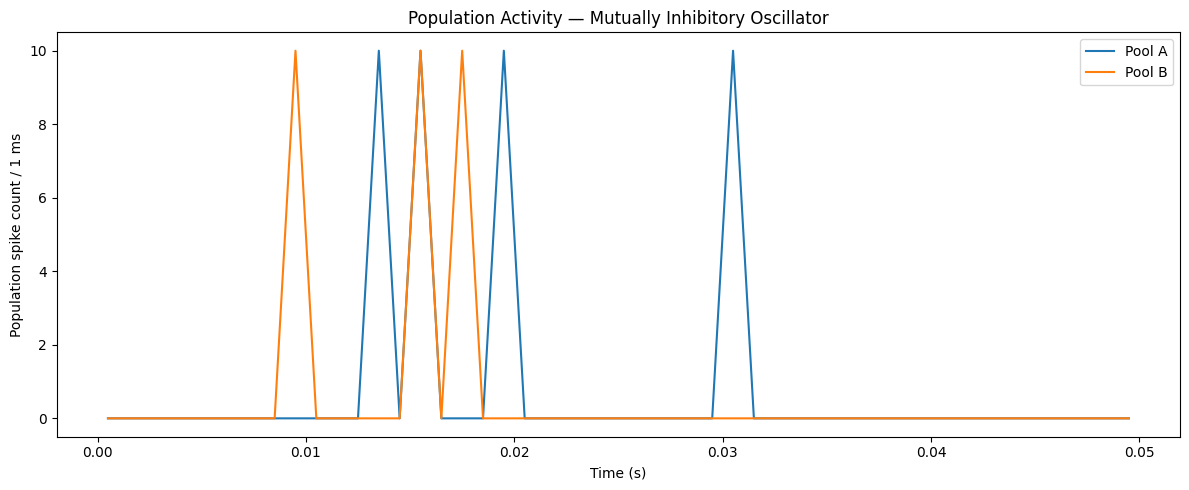

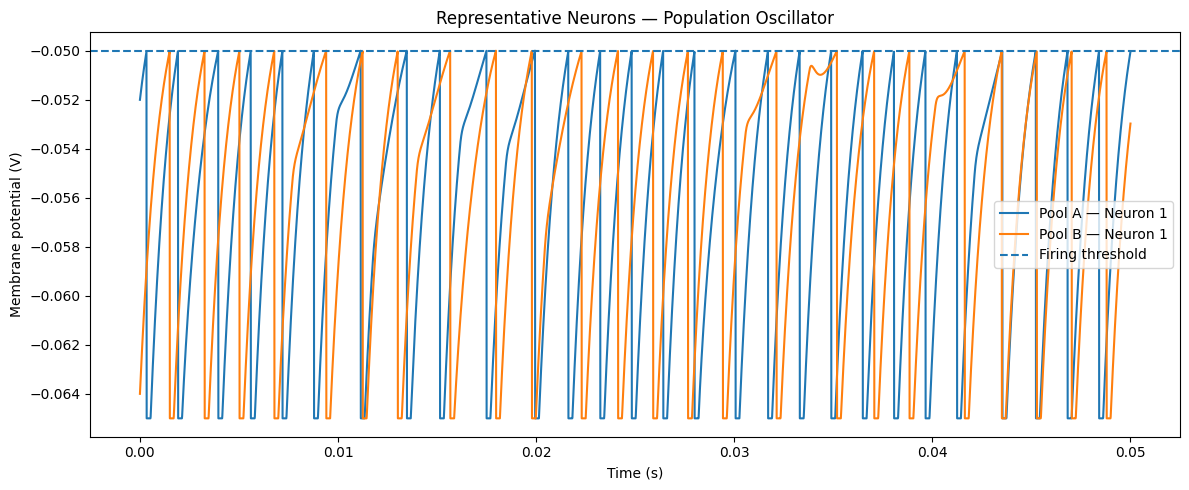

In [6]:
# ============================================================
# FINAL OSCILLATION ANALYSIS
# ============================================================

threshold = -0.050

# Detecting threshold crossings for every neuron
spikes_A = [
    np.where(
        (vm[:-1] < threshold) &
        (vm[1:] >= threshold)
    )[0]
    for vm in vm_A_population
]

spikes_B = [
    np.where(
        (vm[:-1] < threshold) &
        (vm[1:] >= threshold)
    )[0]
    for vm in vm_B_population
]

# Population spike counts
A_spike_count = sum(len(s) for s in spikes_A)
B_spike_count = sum(len(s) for s in spikes_B)

print("=" * 60)
print("POPULATION OSCILLATION ANALYSIS")
print("=" * 60)

print("Pool A total spikes:", A_spike_count)
print("Pool B total spikes:", B_spike_count)

print("Pool A mean spikes/neuron:",
      A_spike_count / N)

print("Pool B mean spikes/neuron:",
      B_spike_count / N)

# ------------------------------------------------------------
# Population activity in 1 ms bins
# ------------------------------------------------------------

bin_size = 0.001
bins = np.arange(
    0,
    time_population[-1] + bin_size,
    bin_size
)

A_activity = np.zeros(len(bins) - 1)
B_activity = np.zeros(len(bins) - 1)

for spikes in spikes_A:
    A_times = spikes * dt
    A_activity += np.histogram(
        A_times,
        bins=bins
    )[0]

for spikes in spikes_B:
    B_times = spikes * dt
    B_activity += np.histogram(
        B_times,
        bins=bins
    )[0]

activity_time = bins[:-1] + bin_size / 2

# ------------------------------------------------------------
# Plot population activity
# ------------------------------------------------------------

plt.figure(figsize=(12, 5))

plt.plot(
    activity_time,
    A_activity,
    label="Pool A"
)

plt.plot(
    activity_time,
    B_activity,
    label="Pool B"
)

plt.xlabel("Time (s)")
plt.ylabel("Population spike count / 1 ms")
plt.title(
    "Population Activity — Mutually Inhibitory Oscillator"
)

plt.legend()
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Plot representative neurons
# ------------------------------------------------------------

plt.figure(figsize=(12, 5))

plt.plot(
    time_population,
    vm_A_population[0],
    label="Pool A — Neuron 1"
)

plt.plot(
    time_population,
    vm_B_population[0],
    label="Pool B — Neuron 1"
)

plt.axhline(
    threshold,
    linestyle="--",
    label="Firing threshold"
)

plt.xlabel("Time (s)")
plt.ylabel("Membrane potential (V)")
plt.title(
    "Representative Neurons — Population Oscillator"
)

plt.legend()
plt.tight_layout()
plt.show()

In [7]:
# ============================================================
# FINAL OSCILLATOR PARAMETER TEST
# ============================================================

# Strengthening reciprocal inhibition and increase synaptic delay
for syn in synchans_A + synchans_B:
    syn.Gbar = 3.0e-9
    syn.tau1 = 0.001
    syn.tau2 = 0.010

# Fixed delay for all reciprocal inhibitory connections
for i in range(N):
    for j in range(N):
        handlers_B[j].synapse[i].delay = 0.010
        handlers_A[j].synapse[i].delay = 0.010

# Restoring constant tonic drive
for neuron in pool_A:
    neuron.inject = 2.0e-9
    neuron.initVm = -0.052

for neuron in pool_B:
    neuron.inject = 1.9e-9
    neuron.initVm = -0.064

# Running fresh simulation
moose.reinit()
moose.start(0.5)

# Extracting fresh recordings
vm_A_population = np.array([
    np.array(table.vector)
    for table in vm_tables_A
])

vm_B_population = np.array([
    np.array(table.vector)
    for table in vm_tables_B
])

time_population = np.arange(
    vm_A_population.shape[1]
) * dt

# Detecting spikes
threshold = -0.050

spikes_A = [
    np.where(
        (vm[:-1] < threshold) &
        (vm[1:] >= threshold)
    )[0]
    for vm in vm_A_population
]

spikes_B = [
    np.where(
        (vm[:-1] < threshold) &
        (vm[1:] >= threshold)
    )[0]
    for vm in vm_B_population
]

A_spike_count = sum(len(s) for s in spikes_A)
B_spike_count = sum(len(s) for s in spikes_B)

print("=" * 60)
print("OSCILLATOR PARAMETER TEST")
print("=" * 60)
print("Gbar:", 3.0e-9, "S")
print("Synaptic delay:", 0.010, "s")
print("Pool A spikes:", A_spike_count)
print("Pool B spikes:", B_spike_count)

OSCILLATOR PARAMETER TEST
Gbar: 3e-09 S
Synaptic delay: 0.01 s
Pool A spikes: 40
Pool B spikes: 40


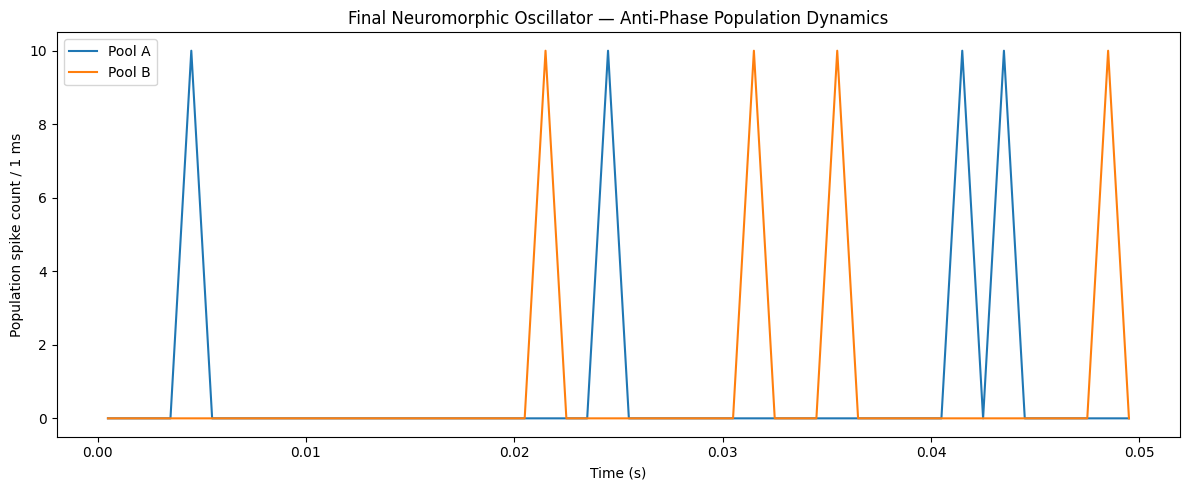

FINAL ANTI-PHASE VERIFICATION
Pool A active bins: 4
Pool B active bins: 4

First Pool A activity: [0.0045 0.0245 0.0415 0.0435]

First Pool B activity: [0.0215 0.0315 0.0355 0.0485]

Pool A activity after 0.03 s: 20.0
Pool B activity after 0.03 s: 30.0


In [8]:
# ============================================================
# FINAL ANTI-PHASE VERIFICATION
# ============================================================

# Population activity in 1 ms bins
bin_size = 0.001

bins = np.arange(
    0,
    time_population[-1] + bin_size,
    bin_size
)

A_activity = np.zeros(len(bins) - 1)
B_activity = np.zeros(len(bins) - 1)

for spikes in spikes_A:
    A_times = spikes * dt
    A_activity += np.histogram(
        A_times,
        bins=bins
    )[0]

for spikes in spikes_B:
    B_times = spikes * dt
    B_activity += np.histogram(
        B_times,
        bins=bins
    )[0]

activity_time = bins[:-1] + bin_size / 2

# ------------------------------------------------------------
# Plotting final population oscillator
# ------------------------------------------------------------

plt.figure(figsize=(12, 5))

plt.plot(
    activity_time,
    A_activity,
    label="Pool A"
)

plt.plot(
    activity_time,
    B_activity,
    label="Pool B"
)

plt.xlabel("Time (s)")
plt.ylabel("Population spike count / 1 ms")
plt.title(
    "Final Neuromorphic Oscillator — Anti-Phase Population Dynamics"
)

plt.legend()
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Calculating population spike times
# ------------------------------------------------------------

A_population_spikes = np.where(A_activity > 0)[0]
B_population_spikes = np.where(B_activity > 0)[0]

print("=" * 60)
print("FINAL ANTI-PHASE VERIFICATION")
print("=" * 60)

print("Pool A active bins:", len(A_population_spikes))
print("Pool B active bins:", len(B_population_spikes))

print()
print("First Pool A activity:",
      activity_time[A_population_spikes[:10]])

print()
print("First Pool B activity:",
      activity_time[B_population_spikes[:10]])

# Checking whether both pools remain active throughout
print()
print("Pool A activity after 0.03 s:",
      np.sum(A_activity[activity_time >= 0.03]))

print("Pool B activity after 0.03 s:",
      np.sum(B_activity[activity_time >= 0.03]))

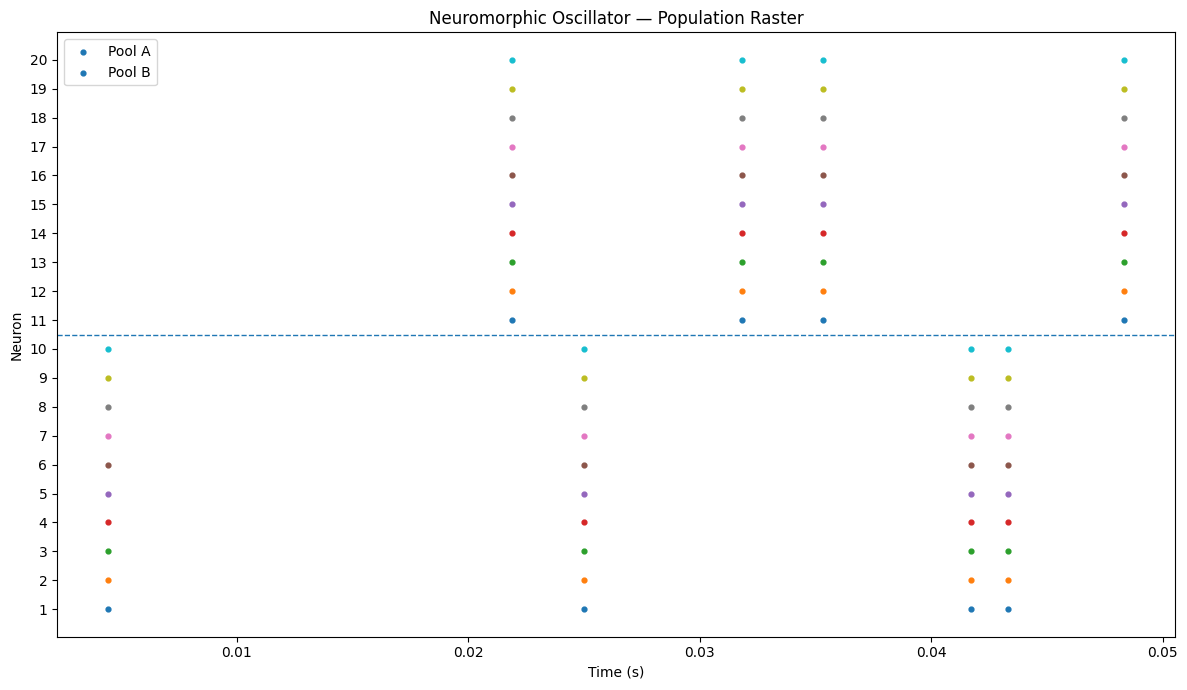

FINAL NETWORK SUMMARY
Total neurons: 20
Pool A neurons: 10
Pool B neurons: 10
Pool A total spikes: 40
Pool B total spikes: 40
Total spikes: 80
Inhibitory connections: 200
Pool A tonic input: 2e-09 A
Pool B tonic input: 1.9e-09 A
Synaptic Gbar: 3e-09 S
Synaptic delay: 0.01 s


In [9]:
# ============================================================
# FINAL NETWORK RASTER PLOT
# ============================================================

plt.figure(figsize=(12, 7))

# Pool A
for i, spikes in enumerate(spikes_A):
    spike_times = spikes * dt
    plt.scatter(
        spike_times,
        np.full(len(spike_times), i + 1),
        s=12,
        label="Pool A" if i == 0 else None
    )

# Pool B
for i, spikes in enumerate(spikes_B):
    spike_times = spikes * dt
    plt.scatter(
        spike_times,
        np.full(len(spike_times), N + i + 1),
        s=12,
        label="Pool B" if i == 0 else None
    )

plt.axhline(
    N + 0.5,
    linestyle="--",
    linewidth=1
)

plt.xlabel("Time (s)")
plt.ylabel("Neuron")
plt.title(
    "Neuromorphic Oscillator — Population Raster"
)

plt.yticks(
    list(range(1, 2 * N + 1))
)

plt.legend()
plt.tight_layout()
plt.show()

print("=" * 60)
print("FINAL NETWORK SUMMARY")
print("=" * 60)

print("Total neurons:", 2 * N)
print("Pool A neurons:", N)
print("Pool B neurons:", N)

print("Pool A total spikes:", A_spike_count)
print("Pool B total spikes:", B_spike_count)

print("Total spikes:",
      A_spike_count + B_spike_count)

print("Inhibitory connections:", 2 * N * N)

print("Pool A tonic input:", pool_A[0].inject, "A")
print("Pool B tonic input:", pool_B[0].inject, "A")

print("Synaptic Gbar:", synchans_A[0].Gbar, "S")
print("Synaptic delay:", handlers_A[0].synapse[0].delay, "s")

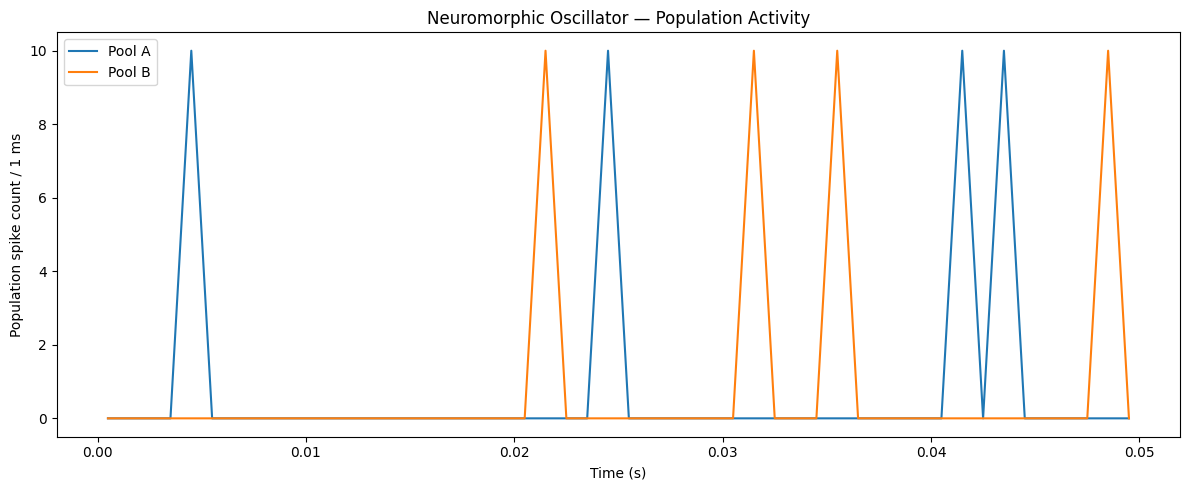

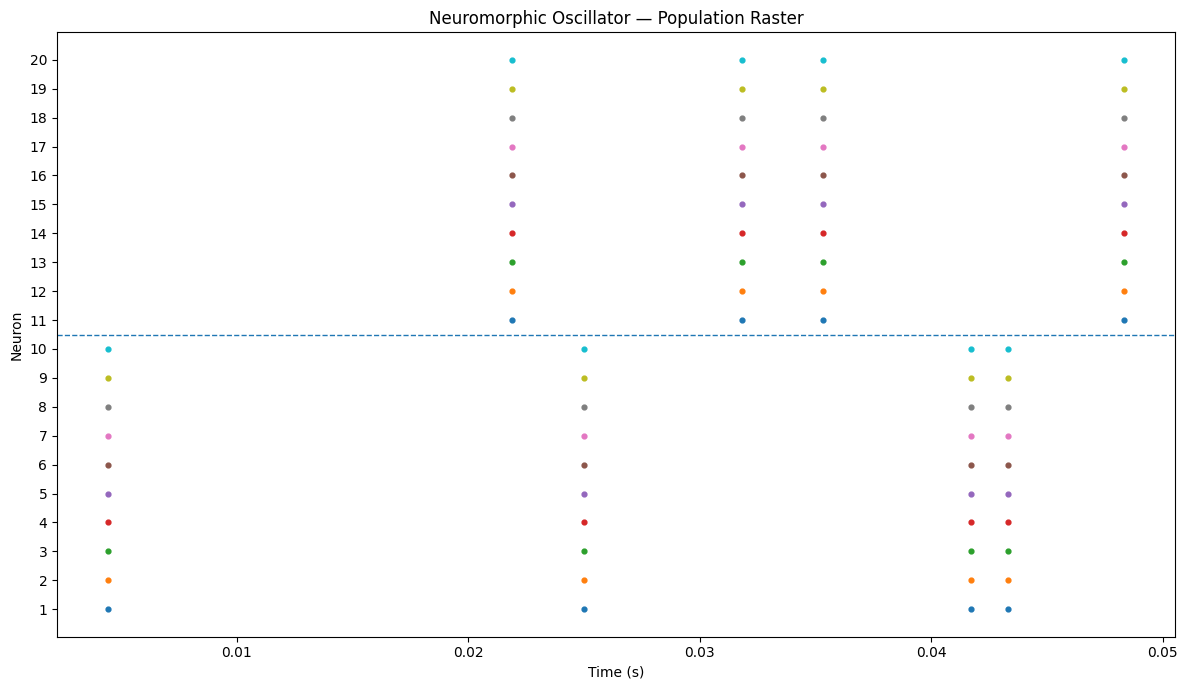

PNG files saved successfully.
population_activity.png
population_raster.png


In [10]:
# ============================================================
# SAVing FINAL OUTPUT FIGURES
# ============================================================

# ---------- Population activity ----------
plt.figure(figsize=(12, 5))

plt.plot(
    activity_time,
    A_activity,
    label="Pool A"
)

plt.plot(
    activity_time,
    B_activity,
    label="Pool B"
)

plt.xlabel("Time (s)")
plt.ylabel("Population spike count / 1 ms")
plt.title(
    "Neuromorphic Oscillator — Population Activity"
)

plt.legend()
plt.tight_layout()

plt.savefig(
    "population_activity.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ---------- Raster plot ----------
plt.figure(figsize=(12, 7))

for i, spikes in enumerate(spikes_A):
    spike_times = spikes * dt

    plt.scatter(
        spike_times,
        np.full(len(spike_times), i + 1),
        s=12
    )

for i, spikes in enumerate(spikes_B):
    spike_times = spikes * dt

    plt.scatter(
        spike_times,
        np.full(len(spike_times), N + i + 1),
        s=12
    )

plt.axhline(
    N + 0.5,
    linestyle="--",
    linewidth=1
)

plt.xlabel("Time (s)")
plt.ylabel("Neuron")
plt.title(
    "Neuromorphic Oscillator — Population Raster"
)

plt.yticks(range(1, 2 * N + 1))

plt.tight_layout()

plt.savefig(
    "population_raster.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("PNG files saved successfully.")
print("population_activity.png")
print("population_raster.png")